# 01 — Molecular Dataset Audit: Orthohantavirus S/M/L segments

## Project question

**How do S, M and L segment sequences differ across major Orthohantavirus species, and can sequence-level features support molecular classification and epidemiological interpretation?**

This notebook performs the first quality audit of the molecular dataset built from NCBI/GenBank.

The goal is not yet to build a model, but to answer a first critical question:

**Is the molecular dataset clean, biologically plausible and balanced enough for downstream sequence analysis?**

We will inspect:

- number of sequences retained after quality control;
- species and segment composition;
- sequence length distributions;
- GC content;
- ambiguous bases;
- completeness status;
- country and collection date coverage;
- potential limitations for downstream phylogeny and classification.

In [3]:
pip install pandas numpy matplotlib openpyxl ipykernel

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 9.9/9.9 MB 73.1 MB/s  0:00:00
   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
   ---------------------------------------- 12.5/12.5 MB 75.8 MB/s  0:00:00
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 8.3/8.3 MB 75.5 MB/s  0:00:00
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True


## 1. Project paths

We define the main project folders.

The notebook is expected to be located in:

```text
notebooks/01_molecular_dataset_audit.ipynb

In [6]:
def find_project_root() -> Path:
    """
    Try to find the project root based on the expected processed data folder.
    This allows the notebook to run from the project root or from notebooks/.
    """
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
    ]
    
    expected_file = Path("data/processed/orthohantavirus_sequences_clean_strict.csv")
    
    for candidate in candidates:
        if (candidate / expected_file).exists():
            return candidate.resolve()
    
    return Path.cwd().resolve()


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("TABLES_DIR:", TABLES_DIR)

PROJECT_ROOT: C:\Users\Utilisateur\Documents\GitHub\Hantavirus-Analysis
DATA_DIR: C:\Users\Utilisateur\Documents\GitHub\Hantavirus-Analysis\data\processed
FIGURES_DIR: C:\Users\Utilisateur\Documents\GitHub\Hantavirus-Analysis\reports\figures
TABLES_DIR: C:\Users\Utilisateur\Documents\GitHub\Hantavirus-Analysis\reports\tables


## 2. Load processed datasets

We load the three main files produced by the molecular dataset builder:

- `orthohantavirus_sequences_clean_all.csv`
- `orthohantavirus_sequences_clean_strict.csv`
- `qc_summary.csv`

The `clean_all` dataset contains cleaned sequences after segment identification and duplicate removal.

The `clean_strict` dataset contains sequences that passed stricter biological length filters.

The `qc_summary` file summarizes the filtering process.

In [7]:
clean_all_path = DATA_DIR / "orthohantavirus_sequences_clean_all.csv"
clean_strict_path = DATA_DIR / "orthohantavirus_sequences_clean_strict.csv"
qc_summary_path = DATA_DIR / "qc_summary.csv"

missing_files = [
    path for path in [clean_all_path, clean_strict_path, qc_summary_path]
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing expected files:\n"
        + "\n".join(str(path) for path in missing_files)
    )

clean_all = pd.read_csv(clean_all_path)
strict = pd.read_csv(clean_strict_path)
qc_summary = pd.read_csv(qc_summary_path)

print("clean_all shape:", clean_all.shape)
print("strict shape:", strict.shape)
print("qc_summary shape:", qc_summary.shape)

clean_all shape: (6747, 33)
strict shape: (3165, 33)
qc_summary shape: (22, 5)


In [8]:
clean_all.head()

,accession,accession_no_version,description,package,target_short_name,target_scientific_name,target_taxid,species,taxid,segment,length,gc_content,seq_sha256,length_qc_flag,freq_A,freq_C,freq_G,freq_T,n_count,ambiguous_other_count,ambiguous_rate,valid_like_count,species_ncbi,taxid_ncbi,isolate,host,country,region,collection_date,nuc_completeness,segment_metadata,metadata_title,is_duplicate_seq_within_species_segment
0,AH011553.2,AH011553,"AH011553.2 Andes virus RNA polymerase gene, pa...",andes_1980456,andes,Orthohantavirus andesense,1980456,Orthohantavirus andesense,1980456,L,431,0.401813,1f8775a4b2efb66cf66cd3f195839f22c46e5da78a809a...,too_short_for_segment,0.280967,0.172205,0.229607,0.317221,100,0,0.232019,431,NaN,1980456,AH-1,NaN,NaN,NaN,NaN,PARTIAL,L,NaN,False
1,KF581136.1,KF581136,KF581136.1 Castelo dos Sonhos virus isolate 76...,andes_1980456,andes,Orthohantavirus andesense,1980456,Orthohantavirus andesense,139033,L,572,0.384615,fead7384060a3e2ef13fd242f47d112c7de54509f01822...,too_short_for_segment,0.325175,0.148601,0.236014,0.290210,0,0,0.000000,572,NaN,139033,769,NaN,Peru,NaN,2010,PARTIAL,L,NaN,False
2,AF324900.1,AF324900,AF324900.1 Andes virus strain AH-1 segment L p...,andes_1980456,andes,Orthohantavirus andesense,1980456,Orthohantavirus andesense,1980456,L,606,0.349835,ad12cdb8ff3e6f4adf2c70f77efe2a9b5b27e407d34282...,too_short_for_segment,0.326733,0.145215,0.204620,0.323432,0,0,0.000000,606,NaN,1980456,AH-1,NaN,NaN,NaN,NaN,PARTIAL,L,NaN,False
3,PQ373861.1,PQ373861,PQ373861.1 Orthohantavirus andesense isolate G...,andes_1980456,andes,Orthohantavirus andesense,1980456,Orthohantavirus andesense,1980456,L,1675,0.376716,8dcd937b6a6dfe5e4effaa7dc5e9077c919d1a5176f07c...,too_short_for_segment,0.315224,0.146866,0.229851,0.308060,0,0,0.000000,1675,NaN,1980456,Guachipas 2024,NaN,"Argentina: Guachipas, Salta",NaN,2024,PARTIAL,NaN,NaN,False
4,PP504849.1,PP504849,PP504849.1 Orthohantavirus andesense isolate B...,andes_1980456,andes,Orthohantavirus andesense,1980456,Orthohantavirus andesense,1980456,L,3892,0.374807,9fbbe53fe9b90d3fdd76c6f6aaea89652a5919771694cf...,too_short_for_segment,0.321851,0.152442,0.222365,0.303342,0,2,0.000514,3890,NaN,1980456,BA02_VVD480,NaN,Argentina: Buenos Aires,NaN,2002,PARTIAL,L,NaN,False


In [9]:
strict.head()

,accession,accession_no_version,description,package,target_short_name,target_scientific_name,target_taxid,species,taxid,segment,length,gc_content,seq_sha256,length_qc_flag,freq_A,freq_C,freq_G,freq_T,n_count,ambiguous_other_count,ambiguous_rate,valid_like_count,species_ncbi,taxid_ncbi,isolate,host,country,region,collection_date,nuc_completeness,segment_metadata,metadata_title,is_duplicate_seq_within_species_segment
0,OR405523.1,OR405523,OR405523.1 Orthohantavirus andesense isolate A...,andes_1980456,andes,Orthohantavirus andesense,1980456,Orthohantavirus andesense,1980456,L,5924,0.364619,41cf8c36ea8edd0639acafb20216d7fc61062a86626ff3...,within_expected_range,0.334909,0.153612,0.211006,0.300473,0,0,0.00000,5924,NaN,1980456,ANDV-CH-LS-2016,NaN,Switzerland,NaN,2016,PARTIAL,L,NaN,False
1,OR405522.1,OR405522,OR405522.1 Orthohantavirus andesense isolate A...,andes_1980456,andes,Orthohantavirus andesense,1980456,Orthohantavirus andesense,1980456,L,6244,0.366170,64ba088c811d33c99114c73bd8ab3251a7ed1acbfb24ca...,within_expected_range,0.334294,0.153932,0.212238,0.299535,1,0,0.00016,6244,NaN,1980456,ANDV-CH-LS-2022,NaN,Switzerland,NaN,2022,PARTIAL,L,NaN,False
2,OP555736.1,OP555736,OP555736.1 Orthohantavirus andesense isolate A...,andes_1980456,andes,Orthohantavirus andesense,1980456,Orthohantavirus andesense,1980456,L,6443,0.375136,76b8a88cf905dd01b506cb8f8cd3c5ecbac3e1b75ca69e...,within_expected_range,0.326711,0.158311,0.216824,0.298153,0,0,0.00000,6443,NaN,1980456,Arg-h484,NaN,Argentina,NaN,NaN,PARTIAL,L,NaN,False
3,PP151167.1,PP151167,PP151167.1 Orthohantavirus andesense isolate B...,andes_1980456,andes,Orthohantavirus andesense,1980456,Orthohantavirus andesense,1980456,L,6443,0.373584,18d287f2f8910c2ed4ab05a075470204ed8134ea43a782...,within_expected_range,0.326711,0.156914,0.216669,0.299705,0,0,0.00000,6443,NaN,1980456,BA02_VO483,NaN,Argentina: Buenos Aires,NaN,2002,PARTIAL,L,NaN,False
4,PP151168.1,PP151168,PP151168.1 Orthohantavirus andesense isolate B...,andes_1980456,andes,Orthohantavirus andesense,1980456,Orthohantavirus andesense,1980456,L,6443,0.372963,59e469e67f7ac04af3191a4bd404f0e82a06d1ee385d3f...,within_expected_range,0.327332,0.156759,0.216204,0.299705,0,0,0.00000,6443,NaN,1980456,BA02_RJF487,NaN,Argentina: Buenos Aires,NaN,2002,PARTIAL,L,NaN,False


In [10]:
qc_summary

,metric,value,species,segment,flag
0,original_sequences,9412,NaN,NaN,NaN
1,with_segment_SML,8647,NaN,NaN,NaN
2,after_exact_dedup_within_species_segment,6747,NaN,NaN,NaN
3,strict_with_expected_length,3165,NaN,NaN,NaN
4,clean_all_count_by_species_segment,67,Orthohantavirus andesense,L,NaN
5,clean_all_count_by_species_segment,307,Orthohantavirus andesense,M,NaN
6,clean_all_count_by_species_segment,177,Orthohantavirus andesense,S,NaN
7,clean_all_count_by_species_segment,574,Orthohantavirus hantanense,L,NaN
8,clean_all_count_by_species_segment,658,Orthohantavirus hantanense,M,NaN
9,clean_all_count_by_species_segment,576,Orthohantavirus hantanense,S,NaN


## 3. Column audit

Before analyzing the dataset, we check whether the expected columns are present.

Important columns include:

- accession;
- species;
- segment;
- sequence length;
- GC content;
- ambiguous base rate;
- country;
- collection date;
- nucleotide completeness.

In [11]:
expected_columns = [
    "accession",
    "species",
    "target_short_name",
    "target_scientific_name",
    "segment",
    "length",
    "gc_content",
    "n_count",
    "ambiguous_other_count",
    "ambiguous_rate",
    "host",
    "country",
    "collection_date",
    "nuc_completeness",
    "length_qc_flag",
]

column_audit = pd.DataFrame({
    "column": expected_columns,
    "in_clean_all": [column in clean_all.columns for column in expected_columns],
    "in_strict": [column in strict.columns for column in expected_columns],
})

column_audit

,column,in_clean_all,in_strict
0,accession,True,True
1,species,True,True
2,target_short_name,True,True
3,target_scientific_name,True,True
4,segment,True,True
5,length,True,True
6,gc_content,True,True
7,n_count,True,True
8,ambiguous_other_count,True,True
9,ambiguous_rate,True,True


In [12]:
missing_expected = column_audit.loc[~column_audit["in_strict"], "column"].tolist()

if missing_expected:
    print("Missing expected columns in strict dataset:")
    print(missing_expected)
else:
    print("All expected columns are present in the strict dataset.")

All expected columns are present in the strict dataset.


### First observations

The processed molecular files were successfully loaded.

The strict dataset will be used as the main quality-controlled dataset for the first molecular audit.

At this stage, the objective is to verify that the dataset contains the expected biological information: viral species, genomic segment, sequence length, GC content, ambiguity rate and metadata such as country and collection date.

## 4. Quality-control filtering funnel

We first inspect how many sequences were retained at each filtering step.

This helps us understand how strict the cleaning process was and how many sequences remain available for downstream molecular analysis.

In [13]:
qc_funnel = qc_summary.copy()

qc_funnel["value"] = pd.to_numeric(qc_funnel["value"], errors="coerce")
qc_funnel = qc_funnel.dropna(subset=["value"])

qc_funnel

,metric,value,species,segment,flag
0,original_sequences,9412,NaN,NaN,NaN
1,with_segment_SML,8647,NaN,NaN,NaN
2,after_exact_dedup_within_species_segment,6747,NaN,NaN,NaN
3,strict_with_expected_length,3165,NaN,NaN,NaN
4,clean_all_count_by_species_segment,67,Orthohantavirus andesense,L,NaN
5,clean_all_count_by_species_segment,307,Orthohantavirus andesense,M,NaN
6,clean_all_count_by_species_segment,177,Orthohantavirus andesense,S,NaN
7,clean_all_count_by_species_segment,574,Orthohantavirus hantanense,L,NaN
8,clean_all_count_by_species_segment,658,Orthohantavirus hantanense,M,NaN
9,clean_all_count_by_species_segment,576,Orthohantavirus hantanense,S,NaN


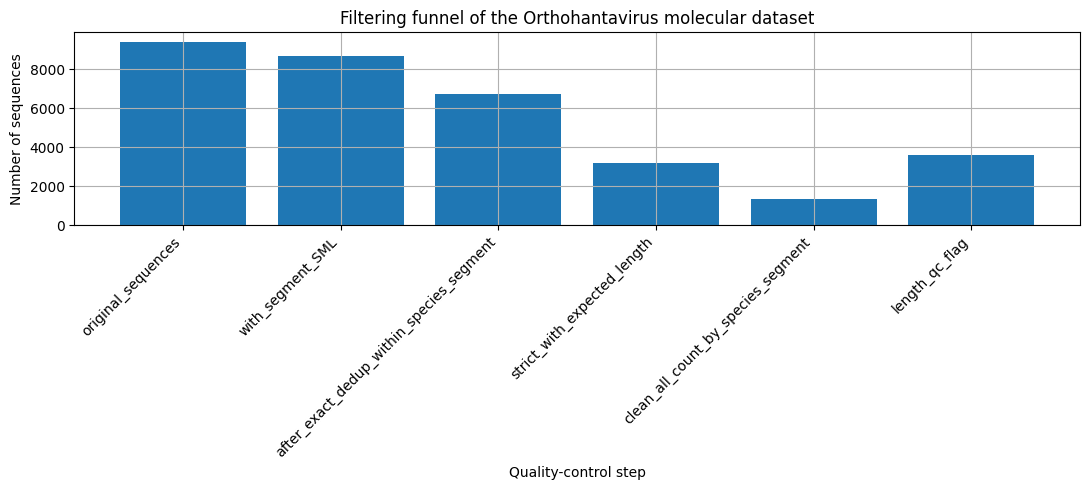

In [14]:
plt.figure(figsize=(11, 5))

plt.bar(qc_funnel["metric"], qc_funnel["value"])

plt.title("Filtering funnel of the Orthohantavirus molecular dataset")
plt.xlabel("Quality-control step")
plt.ylabel("Number of sequences")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_filtering_funnel.png", dpi=300)
plt.show()

### Interpretation

The filtering funnel shows how the initial NCBI sequence collection was progressively reduced to a cleaner molecular dataset.

This step is important because raw public sequence databases may include incomplete entries, duplicate sequences, poorly annotated records or sequences that are not suitable for full segment-level comparison.

The strict dataset is therefore smaller than the original download, but more appropriate for downstream molecular analyses.

## 5. Species composition

We now inspect how many sequences are available for each target Orthohantavirus species.

This is important because strong species imbalance may influence downstream clustering, PCA or classification models.

In [15]:
species_col = "target_scientific_name" if "target_scientific_name" in strict.columns else "species"

species_counts = (
    strict[species_col]
    .fillna("Unknown")
    .value_counts()
    .rename_axis("species")
    .reset_index(name="n_sequences")
)

species_counts

,species,n_sequences
0,Orthohantavirus hantanense,1058
1,Orthohantavirus puumalaense,876
2,Orthohantavirus seoulense,815
3,Orthohantavirus andesense,233
4,Orthohantavirus sinnombreense,183


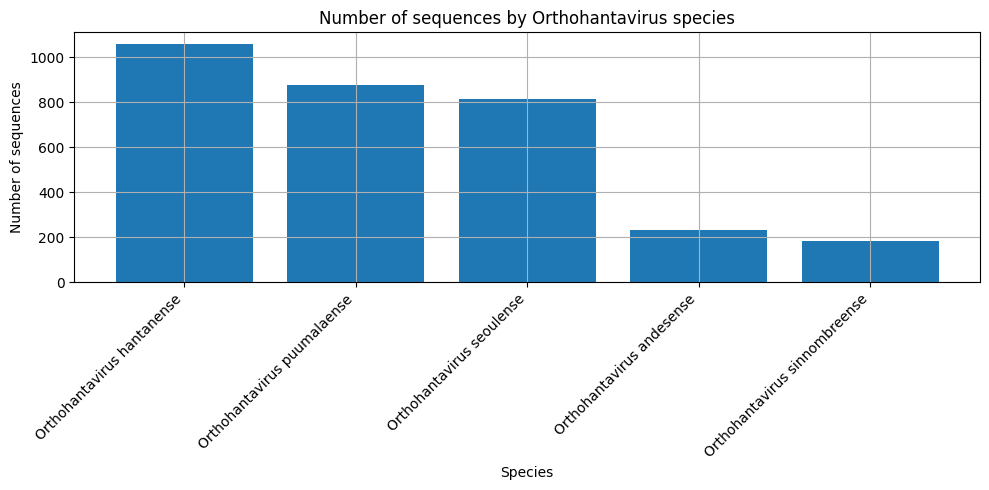

In [16]:
plt.figure(figsize=(10, 5))

plt.bar(species_counts["species"], species_counts["n_sequences"])

plt.title("Number of sequences by Orthohantavirus species")
plt.xlabel("Species")
plt.ylabel("Number of sequences")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_species_counts.png", dpi=300)
plt.show()

## 6. Segment composition

Orthohantaviruses have a segmented RNA genome composed of three segments: S, M and L.

We inspect the number of available sequences for each segment.

In [17]:
segment_counts = (
    strict["segment"]
    .fillna("Unknown")
    .value_counts()
    .rename_axis("segment")
    .reset_index(name="n_sequences")
)

segment_counts

,segment,n_sequences
0,S,1553
1,M,894
2,L,718


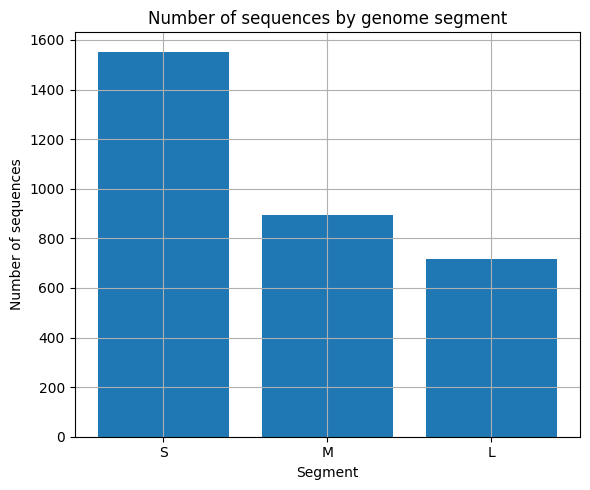

In [18]:
plt.figure(figsize=(6, 5))

plt.bar(segment_counts["segment"], segment_counts["n_sequences"])

plt.title("Number of sequences by genome segment")
plt.xlabel("Segment")
plt.ylabel("Number of sequences")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_segment_counts.png", dpi=300)
plt.show()

## 7. Species by segment composition

We now cross-tabulate species and genome segments.

This helps us check whether all target species have enough S, M and L sequences for comparative analysis.

In [19]:
species_segment_counts = pd.crosstab(
    strict[species_col].fillna("Unknown"),
    strict["segment"].fillna("Unknown")
)

species_segment_counts

segment,L,M,S
target_scientific_name,,,
Orthohantavirus andesense,62,75,96
Orthohantavirus hantanense,272,334,452
Orthohantavirus puumalaense,125,140,611
Orthohantavirus seoulense,207,284,324
Orthohantavirus sinnombreense,52,61,70


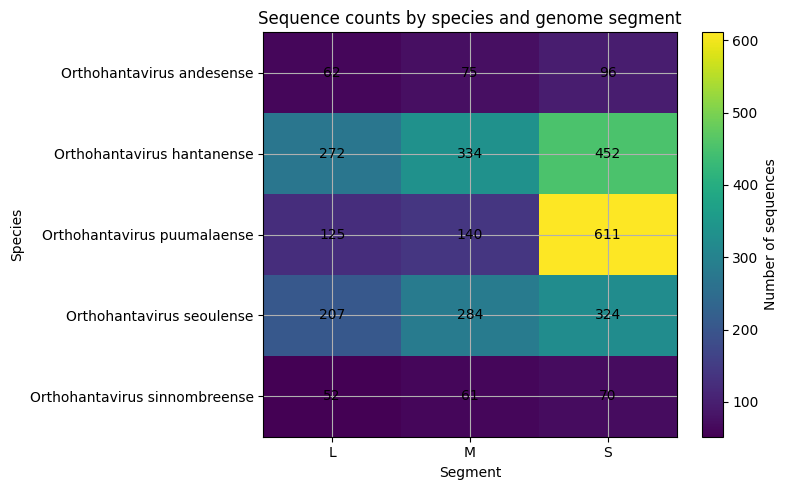

In [20]:
matrix = species_segment_counts.copy()

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(matrix.values, aspect="auto")

ax.set_xticks(np.arange(matrix.shape[1]))
ax.set_yticks(np.arange(matrix.shape[0]))

ax.set_xticklabels(matrix.columns)
ax.set_yticklabels(matrix.index)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        ax.text(j, i, int(matrix.iloc[i, j]), ha="center", va="center")

ax.set_title("Sequence counts by species and genome segment")
ax.set_xlabel("Segment")
ax.set_ylabel("Species")

fig.colorbar(im, ax=ax, label="Number of sequences")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_species_segment_heatmap.png", dpi=300)
plt.show()

### Interpretation

The strict molecular dataset contains sequences from the five selected Orthohantavirus species and from the three expected genome segments: S, M and L.

The dataset is not perfectly balanced. Some species are represented by more sequences than others, and the S segment is usually more abundant than the M and L segments.

This imbalance should be kept in mind for downstream analyses. For descriptive molecular analysis, the dataset remains useful. For machine learning classification, stratified train/test splits or class balancing strategies may be needed.

## 8. Audit biologique des longueurs des segments

Nous allons maintenant vérifier si les longueurs des séquences du dataset strict sont cohérentes avec ce que l’on attend biologiquement pour les trois segments du génome des Orthohantavirus.

Cette étape est essentielle car elle permet de confirmer que les séquences conservées après filtrage correspondent bien à des segments S, M et L plausibles, et non à des fragments aberrants ou trop incomplets.

In [21]:
length_stats_by_segment = strict.groupby("segment")["length"].describe().round(2)
length_stats_by_segment

,count,mean,std,min,25%,50%,75%,max
segment,,,,,,,,
L,718.0,6496.31,101.91,5705.0,6490.5,6530.0,6533.0,7373.0
M,894.0,3590.08,107.93,3009.0,3606.0,3616.0,3651.0,3797.0
S,1553.0,1598.85,265.00,903.0,1302.0,1696.0,1772.0,3482.0


### Notes
Ici, on calcule des statistiques descriptives sur la longueur des séquences pour chaque segment viral.

Concrètement, on regroupe les séquences selon leur segment (**S, M ou L**) puis on regarde des indicateurs comme :

- le nombre de séquences ;
- la moyenne ;
- l’écart-type ;
- la longueur minimale ;
- la médiane ;
- la longueur maximale.

Cela permet de vérifier si les segments suivent des ordres de grandeur biologiquement cohérents.


In [22]:
length_stats_by_species_segment = (
    strict
    .groupby([species_col, "segment"])["length"]
    .describe()
    .round(2)
)

length_stats_by_species_segment

count     mean     std     min      25%     50%      75%     max
target_scientific_name        segment                                                                  
Orthohantavirus andesense     L         62.0  6511.52   92.90  5924.0  6478.25  6539.5  6546.75  6623.0
                              M         75.0  3631.09   59.75  3386.0  3633.50  3651.0  3658.50  3696.0
                              S         96.0  1715.09  336.29   924.0  1827.75  1857.0  1871.00  2122.0
Orthohantavirus hantanense    L        272.0  6515.28   35.84  6322.0  6530.00  6530.0  6530.00  6550.0
                              M        334.0  3592.97   67.31  3070.0  3615.00  3616.0  3616.00  3648.0
                              S        452.0  1641.73  161.54   978.0  1660.00  1696.0  1699.00  3482.0
Orthohantavirus puumalaense   L        125.0  6502.74   81.19  5972.0  6490.00  6523.0  6550.00  6588.0
                              M        140.0  3565.27  154.92  3058.0  3447.00  3640.0  3679.00  3712.0
                              S        611.0  1510.79  302.59   903.0  1299.00  1590.0  1814.50  1942.0
Orthohantavirus seoulense     L        207.0  6465.04  127.30  5742.0  6456.00  6530.0  6530.00  6580.0
                              M        284.0  3576.09  121.78  3009.0  3551.00  3651.0  3651.00  3653.0
                              S        324.0  1637.13  221.64   903.0  1536.00  1756.0  1772.00  2123.0
Orthohantavirus sinnombreense L         52.0  6487.94  202.57  5705.0  6516.25  6541.0  6547.25  7373.0
                              M         61.0  3645.87  102.87  3080.0  3643.00  3668.0  3690.00  3797.0
                              S         70.0  1753.91  288.22  1074.0  1469.00  1952.0  2007.75  2130.0

### Notes

Cette fois, on affine l’analyse en regardant les longueurs non seulement par segment, mais aussi par espèce virale.

On observe pour chaque espèce de virus la distribution des longueurs de ses segments **S, M et L**.

Cela permet de voir si certaines espèces ont des profils de longueur particuliers ou si l’ensemble reste globalement homogène entre virus.

In [23]:
length_stats_by_segment.to_csv(TABLES_DIR / "05_length_stats_by_segment.csv")
length_stats_by_species_segment.to_csv(TABLES_DIR / "06_length_stats_by_species_segment.csv")

print("Tables saved in:", TABLES_DIR)

Tables saved in: C:\Users\Utilisateur\Documents\GitHub\Hantavirus-Analysis\reports\tables


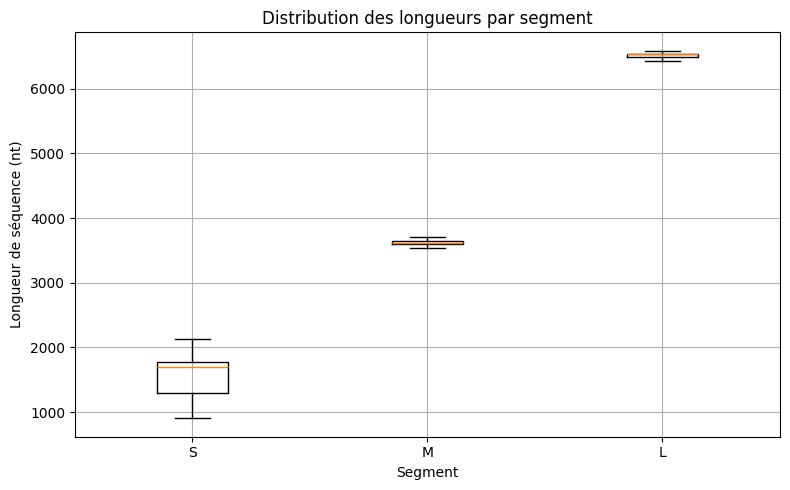

In [24]:
segment_order = [s for s in ["S", "M", "L"] if s in strict["segment"].dropna().unique()]

plt.figure(figsize=(8, 5))

data = [
    strict.loc[strict["segment"] == seg, "length"].dropna()
    for seg in segment_order
]

plt.boxplot(data, labels=segment_order, showfliers=False)

plt.title("Distribution des longueurs par segment")
plt.xlabel("Segment")
plt.ylabel("Longueur de séquence (nt)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_length_boxplot_by_segment.png", dpi=300)
plt.show()

### Notes

Dans cette figure, on représente les longueurs des séquences sous forme de **boxplots** pour les segments **S, M et L**.

Ce graphique permet de comparer visuellement :

- les médianes ;
- la dispersion ;
- les différences globales de taille entre les segments.

C’est un très bon moyen de vérifier rapidement si le segment **S** est bien le plus court, **M** intermédiaire, et **L** le plus long, comme attendu biologiquement.

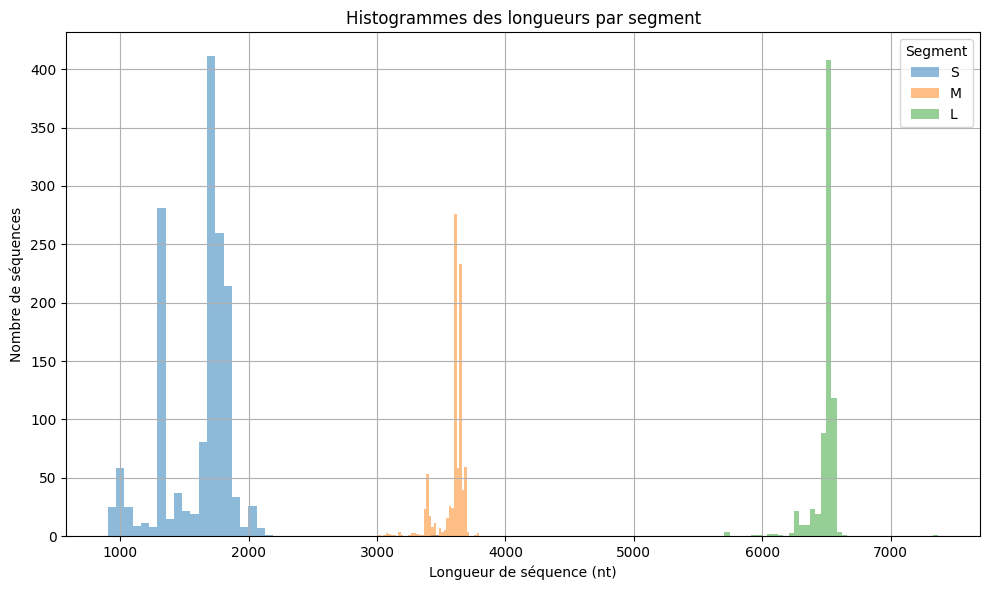

In [25]:
plt.figure(figsize=(10, 6))

for seg in segment_order:
    subset = strict.loc[strict["segment"] == seg, "length"].dropna()
    plt.hist(subset, bins=40, alpha=0.5, label=seg)

plt.title("Histogrammes des longueurs par segment")
plt.xlabel("Longueur de séquence (nt)")
plt.ylabel("Nombre de séquences")
plt.legend(title="Segment")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_length_histogram_by_segment.png", dpi=300)
plt.show()

### Notes

Ici, on trace des **histogrammes** pour observer la distribution des longueurs des séquences dans chaque segment.

Contrairement au boxplot, ce graphique montre davantage la forme globale des distributions :

- où se concentrent les longueurs ;
- si les longueurs sont très étalées ;
- s’il existe plusieurs groupes ;
- ou s’il y a des profils atypiques.

Cela nous aide à juger si les séquences du dataset strict semblent homogènes et biologiquement plausibles.

In [26]:
mean_length_species_segment = (
    strict
    .groupby([species_col, "segment"])["length"]
    .mean()
    .round(2)
    .unstack()
)

mean_length_species_segment

segment,L,M,S
target_scientific_name,,,
Orthohantavirus andesense,6511.52,3631.09,1715.09
Orthohantavirus hantanense,6515.28,3592.97,1641.73
Orthohantavirus puumalaense,6502.74,3565.27,1510.79
Orthohantavirus seoulense,6465.04,3576.09,1637.13
Orthohantavirus sinnombreense,6487.94,3645.87,1753.91


### Notes

Dans ce tableau, on calcule la longueur moyenne des segments **S, M et L** pour chaque espèce virale.

Cela permet d’avoir une vue synthétique des tailles moyennes des segments selon le virus étudié.

On peut ainsi comparer les espèces entre elles et vérifier si leurs profils restent cohérents avec l’organisation attendue du génome viral.

In [27]:
mean_length_species_segment.to_csv(TABLES_DIR / "07_mean_length_by_species_segment.csv")
print("Table saved.")

Table saved.


## Interprétation générale — longueurs des segments

L’analyse des longueurs confirme si le dataset strict est biologiquement crédible.

Si les résultats montrent que :

- les séquences du segment **S** sont les plus courtes ;
- celles du segment **M** sont intermédiaires ;
- et celles du segment **L** sont les plus longues ;

alors cela constitue un bon argument en faveur de la qualité du dataset.

Cette étape est importante car elle montre que les séquences conservées après filtrage semblent bien correspondre à de vrais segments viraux exploitables pour la suite des analyses moléculaires.

## 9. GC content analysis

We now analyze the GC content of the strict molecular dataset.

GC content is the proportion of guanine and cytosine bases in a nucleotide sequence. It is a simple but useful molecular descriptor, because different viral segments or viral species may have slightly different nucleotide composition profiles.

In [28]:
gc_stats_by_segment = strict.groupby("segment")["gc_content"].describe().round(4)
gc_stats_by_segment

,count,mean,std,min,25%,50%,75%,max
segment,,,,,,,,
L,718.0,0.3703,0.0065,0.3479,0.3685,0.3718,0.3746,0.3817
M,894.0,0.3976,0.0055,0.3761,0.3944,0.3982,0.4011,0.4180
S,1553.0,0.4187,0.0196,0.3629,0.4131,0.4236,0.4288,0.4703


### Notes

Ici, on calcule les statistiques descriptives du GC content pour chaque segment viral : **S, M et L**.

Cette étape permet de comparer les trois segments au niveau de leur composition en bases G et C.

Dans notre dataset, on s’attend à observer un gradient assez net :

- le segment **L** a généralement le GC content le plus faible ;
- le segment **M** est intermédiaire ;
- le segment **S** a souvent le GC content le plus élevé.

Cela suggère que les trois segments n’ont pas exactement la même composition nucléotidique, ce qui pourrait devenir une information utile pour la classification moléculaire.

In [29]:
gc_stats_by_species = (
    strict
    .groupby(species_col)["gc_content"]
    .describe()
    .round(4)
)

gc_stats_by_species

,count,mean,std,min,25%,50%,75%,max
target_scientific_name,,,,,,,,
Orthohantavirus andesense,233.0,0.4035,0.0231,0.3617,0.3791,0.4047,0.4218,0.4522
Orthohantavirus hantanense,1058.0,0.4056,0.0248,0.3659,0.3797,0.4013,0.4285,0.4558
Orthohantavirus puumalaense,876.0,0.3967,0.0231,0.3479,0.3836,0.3916,0.4219,0.4441
Orthohantavirus seoulense,815.0,0.4038,0.0240,0.3685,0.3788,0.3998,0.4210,0.4703
Orthohantavirus sinnombreense,183.0,0.3920,0.0174,0.3495,0.3770,0.3918,0.4019,0.4388


### Notes

Ici, on regarde le GC content par espèce virale.

L’objectif est de voir si certaines espèces d’Orthohantavirus ont une composition nucléotidique légèrement différente des autres.

Il faut cependant rester prudent : une différence de GC content entre espèces peut être influencée par la proportion de segments S, M et L disponibles pour chaque espèce. Par exemple, si une espèce possède beaucoup plus de séquences du segment S, son GC content moyen global peut sembler plus élevé.

In [30]:
gc_stats_by_species_segment = (
    strict
    .groupby([species_col, "segment"])["gc_content"]
    .describe()
    .round(4)
)

gc_stats_by_species_segment

count    mean     std     min     25%     50%     75%     max
target_scientific_name        segment                                                               
Orthohantavirus andesense     L         62.0  0.3693  0.0037  0.3617  0.3673  0.3687  0.3691  0.3811
                              M         75.0  0.4048  0.0038  0.3991  0.4031  0.4039  0.4049  0.4180
                              S         96.0  0.4247  0.0081  0.4065  0.4194  0.4237  0.4277  0.4522
Orthohantavirus hantanense    L        272.0  0.3717  0.0032  0.3659  0.3697  0.3711  0.3730  0.3806
                              M        334.0  0.3992  0.0037  0.3867  0.3974  0.3994  0.4010  0.4146
                              S        452.0  0.4308  0.0083  0.4047  0.4271  0.4292  0.4322  0.4558
Orthohantavirus puumalaense   L        125.0  0.3598  0.0070  0.3479  0.3562  0.3570  0.3617  0.3817
                              M        140.0  0.3915  0.0067  0.3761  0.3865  0.3926  0.3944  0.4077
                              S        611.0  0.4054  0.0197  0.3629  0.3872  0.4006  0.4249  0.4441
Orthohantavirus seoulense     L        207.0  0.3744  0.0018  0.3685  0.3733  0.3743  0.3754  0.3796
                              M        284.0  0.3969  0.0039  0.3881  0.3947  0.3963  0.4004  0.4068
                              S        324.0  0.4287  0.0147  0.4016  0.4200  0.4225  0.4279  0.4703
Orthohantavirus sinnombreense L         52.0  0.3726  0.0055  0.3495  0.3718  0.3735  0.3751  0.3803
                              M         61.0  0.3977  0.0043  0.3891  0.3941  0.3975  0.4022  0.4038
                              S         70.0  0.4016  0.0188  0.3736  0.3873  0.3920  0.4164  0.4388

### Notes

Cette analyse est plus fine, car elle compare le GC content en tenant compte à la fois de l’espèce virale et du segment.

C’est important parce que comparer uniquement les espèces peut être trompeur si les segments ne sont pas représentés de manière équilibrée.

Ici, on peut vérifier si le même schéma général se retrouve dans plusieurs espèces :

- segment **L** plus pauvre en GC ;
- segment **M** intermédiaire ;
- segment **S** plus riche en GC.

Si ce motif est répété chez plusieurs espèces, cela renforce l’idée que le segment lui-même influence fortement la composition nucléotidique.

In [31]:
gc_stats_by_segment.to_csv(TABLES_DIR / "08_gc_stats_by_segment.csv")
gc_stats_by_species.to_csv(TABLES_DIR / "09_gc_stats_by_species.csv")
gc_stats_by_species_segment.to_csv(TABLES_DIR / "10_gc_stats_by_species_segment.csv")

print("GC content tables saved in:", TABLES_DIR)

GC content tables saved in: C:\Users\Utilisateur\Documents\GitHub\Hantavirus-Analysis\reports\tables


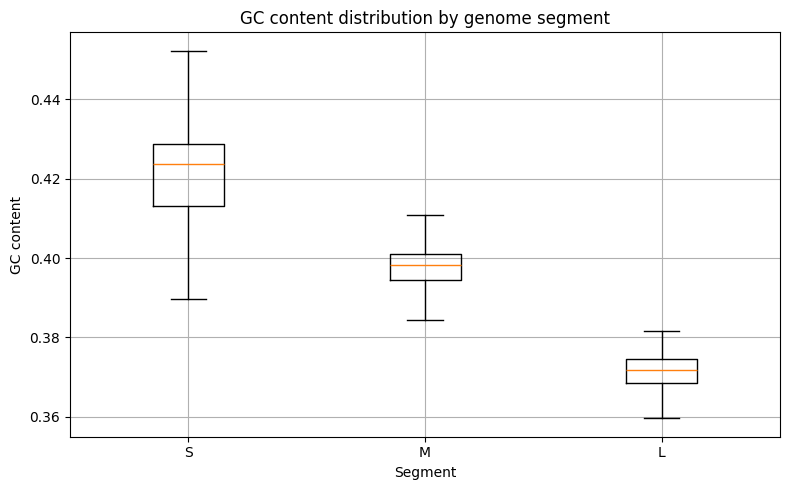

In [32]:
segment_order = [s for s in ["S", "M", "L"] if s in strict["segment"].dropna().unique()]

plt.figure(figsize=(8, 5))

data = [
    strict.loc[strict["segment"] == seg, "gc_content"].dropna()
    for seg in segment_order
]

plt.boxplot(data, labels=segment_order, showfliers=False)

plt.title("GC content distribution by genome segment")
plt.xlabel("Segment")
plt.ylabel("GC content")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_gc_boxplot_by_segment.png", dpi=300)
plt.show()

### Notes

Cette figure compare la distribution du GC content entre les segments **S, M et L**.

Elle est importante car elle montre visuellement que les segments n’ont pas exactement la même composition nucléotidique.

Dans notre dataset, le profil attendu est le suivant :

- **L** présente le GC content le plus faible, autour de 37 % ;
- **M** est intermédiaire, autour de 40 % ;
- **S** est le plus riche en GC, autour de 42 %.

Le segment **S** semble aussi plus variable que les segments **M** et **L**. Cela pourrait refléter une plus grande diversité de séquences, une représentation plus importante dans le dataset ou des différences biologiques entre espèces.

Cette figure suggère déjà que le GC content peut contribuer à distinguer les segments, mais probablement pas suffire seul à distinguer toutes les espèces.

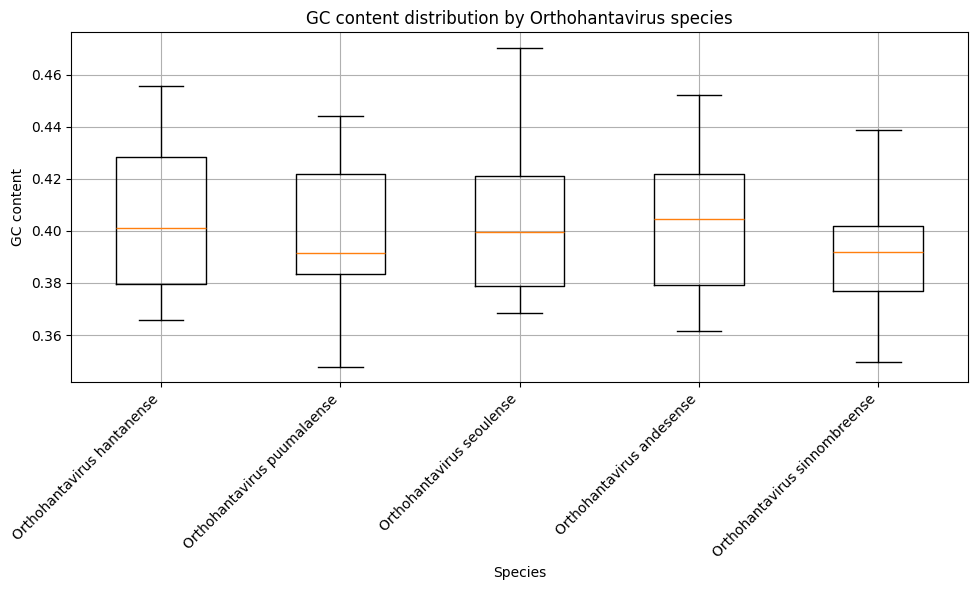

In [33]:
species_order = species_counts["species"].tolist()

plt.figure(figsize=(10, 6))

data = [
    strict.loc[strict[species_col] == species, "gc_content"].dropna()
    for species in species_order
]

plt.boxplot(data, labels=species_order, showfliers=False)

plt.title("GC content distribution by Orthohantavirus species")
plt.xlabel("Species")
plt.ylabel("GC content")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_gc_boxplot_by_species.png", dpi=300)
plt.show()

### Notes

Cette figure compare le GC content entre les différentes espèces d’Orthohantavirus.

On observe normalement que les espèces ont des distributions assez proches, avec des différences moins marquées que celles observées entre segments.

Cela signifie que le GC content semble surtout structuré par le type de segment viral (**S, M ou L**) plutôt que par l’espèce seule.

Quelques espèces peuvent toutefois présenter des tendances légèrement différentes. Par exemple, **Orthohantavirus puumalaense** et **Orthohantavirus sinnombreense** semblent avoir un GC content global un peu plus faible, tandis que **Orthohantavirus hantanense**, **seoulense** et **andesense** sont légèrement plus élevés.

Cependant, cette comparaison doit être interprétée avec prudence, car chaque espèce n’a pas exactement le même nombre de séquences par segment.

In [34]:
mean_gc_species_segment = (
    strict
    .groupby([species_col, "segment"])["gc_content"]
    .mean()
    .round(4)
    .unstack()
)

mean_gc_species_segment

segment,L,M,S
target_scientific_name,,,
Orthohantavirus andesense,0.3693,0.4048,0.4247
Orthohantavirus hantanense,0.3717,0.3992,0.4308
Orthohantavirus puumalaense,0.3598,0.3915,0.4054
Orthohantavirus seoulense,0.3744,0.3969,0.4287
Orthohantavirus sinnombreense,0.3726,0.3977,0.4016


### Notes

Ce tableau résume le GC content moyen pour chaque combinaison espèce × segment.

Il est plus informatif qu’une simple moyenne par espèce, car il permet de comparer les virus segment par segment.

On peut ainsi vérifier si le segment **S** est plus riche en GC dans presque toutes les espèces, et si le segment **L** reste généralement le plus pauvre en GC.

Cette table est utile pour éviter une interprétation trop simpliste des boxplots globaux.

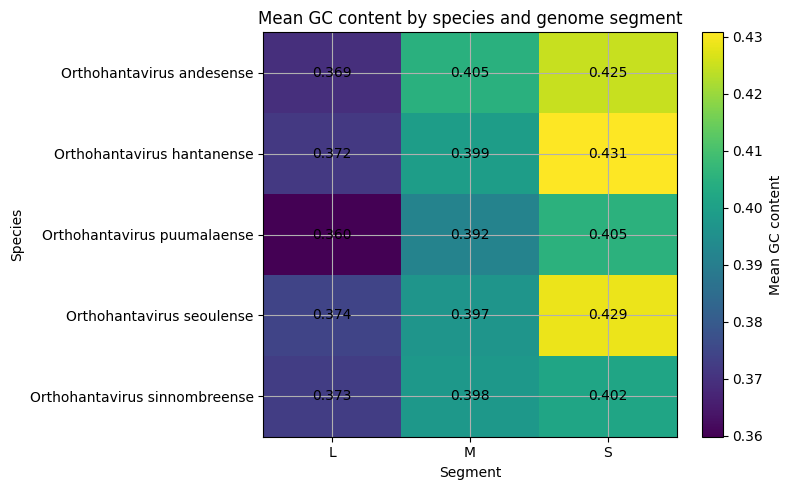

In [35]:
matrix = mean_gc_species_segment.copy()

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(matrix.values, aspect="auto")

ax.set_xticks(np.arange(matrix.shape[1]))
ax.set_yticks(np.arange(matrix.shape[0]))

ax.set_xticklabels(matrix.columns)
ax.set_yticklabels(matrix.index)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        value = matrix.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.3f}", ha="center", va="center")

ax.set_title("Mean GC content by species and genome segment")
ax.set_xlabel("Segment")
ax.set_ylabel("Species")

fig.colorbar(im, ax=ax, label="Mean GC content")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "09_mean_gc_species_segment_heatmap.png", dpi=300)
plt.show()

### Notes

Cette heatmap montre le GC content moyen pour chaque couple **espèce × segment**.

Elle permet de lire rapidement les différences de composition nucléotidique entre segments et entre espèces.

L’analyse attendue est la suivante :

- le segment **L** est généralement le plus faible en GC ;
- le segment **M** est intermédiaire ;
- le segment **S** est souvent le plus élevé ;
- certaines espèces, comme **Puumala** ou **Sin Nombre**, peuvent présenter des valeurs plus basses sur certains segments.

La heatmap confirme donc que le GC content varie de manière structurée. Le segment viral semble être un facteur important, et l’espèce ajoute ensuite des variations plus fines.

In [36]:
mean_gc_species_segment.to_csv(TABLES_DIR / "11_mean_gc_by_species_segment.csv")

print("Mean GC content table saved.")

Mean GC content table saved.


## Interprétation générale — GC content

L’analyse du GC content montre que les trois segments du génome des Orthohantavirus n’ont pas exactement la même composition nucléotidique.

Dans le dataset strict, le segment **L** apparaît généralement comme le moins riche en GC, le segment **M** comme intermédiaire, et le segment **S** comme le plus riche en GC.

Cette différence est visible dans les statistiques descriptives, dans les boxplots et dans la heatmap espèce × segment.

Le GC content semble donc être une feature moléculaire intéressante pour caractériser les segments. En revanche, il ne suffit probablement pas à lui seul pour distinguer parfaitement les espèces virales, car les distributions entre espèces restent assez proches.

Pour une classification plus fine, il faudra utiliser des features plus riches, comme les fréquences de nucléotides, les k-mers ou des approches basées sur l’alignement.

## 10. Sequence quality and ambiguous bases

We now evaluate the quality of the nucleotide sequences by looking at ambiguous bases.

In nucleotide sequence databases, ambiguous positions are often represented by `N`, meaning that the base could not be confidently determined.

This step is important because sequences with too many ambiguous bases may reduce the quality of downstream analyses such as k-mer profiling, clustering or phylogenetic reconstruction.

In [37]:
quality_columns = [
    "n_count",
    "ambiguous_other_count",
    "ambiguous_rate",
]

strict[quality_columns].describe().round(5)

,n_count,ambiguous_other_count,ambiguous_rate
count,3165.00000,3165.00000,3165.00000
mean,15.28310,0.30490,0.00348
std,138.85802,3.83752,0.02799
min,0.00000,0.00000,0.00000
25%,0.00000,0.00000,0.00000
50%,0.00000,0.00000,0.00000
75%,0.00000,0.00000,0.00000
max,3360.00000,118.00000,0.56026


### Notes

Ici, on regarde les statistiques générales liées aux bases ambiguës.

La colonne `n_count` indique le nombre de bases `N` dans chaque séquence. La colonne `ambiguous_other_count` correspond aux autres caractères ambigus éventuels. La colonne `ambiguous_rate` donne la proportion totale de bases ambiguës par rapport à la longueur de la séquence.

Cette étape permet d’évaluer si le dataset strict est globalement propre ou si une partie importante des séquences contient trop d’incertitudes.

In [38]:
high_ambiguity = strict[strict["ambiguous_rate"] > 0.05].copy()

print("Number of sequences with ambiguous_rate > 5%:", len(high_ambiguity))
print("Percentage of strict dataset:", round(len(high_ambiguity) / len(strict) * 100, 2), "%")

high_ambiguity[
    ["accession", species_col, "segment", "length", "n_count", "ambiguous_other_count", "ambiguous_rate"]
].sort_values("ambiguous_rate", ascending=False).head(20)

Number of sequences with ambiguous_rate > 5%: 56
Percentage of strict dataset: 1.77 %


,accession,target_scientific_name,segment,length,n_count,ambiguous_other_count,ambiguous_rate
2983,MZ851454.1,Orthohantavirus sinnombreense,L,6090,3360,52,0.560263
3129,MZ851452.1,Orthohantavirus sinnombreense,S,1950,928,6,0.478974
3034,MZ851453.1,Orthohantavirus sinnombreense,M,3080,1293,32,0.430195
3033,MZ851451.1,Orthohantavirus sinnombreense,L,7373,3099,70,0.429811
2984,MZ851472.1,Orthohantavirus sinnombreense,L,6131,2325,85,0.393084
3047,PX401019.1,Orthohantavirus sinnombreense,M,3641,1320,0,0.362538
3035,MZ851471.1,Orthohantavirus sinnombreense,M,3365,1066,45,0.330163
2989,PX401017.1,Orthohantavirus sinnombreense,L,6311,1910,0,0.302646
2991,MZ851469.1,Orthohantavirus sinnombreense,L,6331,1624,118,0.275154
2193,OQ999170.1,Orthohantavirus seoulense,L,6295,1605,0,0.254964


### Notes

Ici, on identifie les séquences dont plus de 5 % des bases sont ambiguës.

Le seuil de 5 % est un choix pratique pour séparer les séquences globalement exploitables des séquences plus bruitées.

Dans notre dataset, le nombre de séquences dépassant ce seuil devrait rester faible par rapport à l’ensemble du dataset strict. Cela signifie que la majorité des séquences est suffisamment propre pour les analyses exploratoires.

In [39]:
analysis_ready = strict[strict["ambiguous_rate"].fillna(0) <= 0.05].copy()

print("Strict dataset:", len(strict))
print("Analysis-ready dataset:", len(analysis_ready))
print("Removed sequences:", len(strict) - len(analysis_ready))

analysis_ready_path = DATA_DIR / "orthohantavirus_sequences_analysis_ready.csv"
analysis_ready.to_csv(analysis_ready_path, index=False)

print("Saved:", analysis_ready_path)

Strict dataset: 3165
Analysis-ready dataset: 3109
Removed sequences: 56
Saved: C:\Users\Utilisateur\Documents\GitHub\Hantavirus-Analysis\data\processed\orthohantavirus_sequences_analysis_ready.csv


### Notes

Ici, on crée une version plus propre du dataset, appelée `analysis_ready`.

On conserve uniquement les séquences dont le taux de bases ambiguës est inférieur ou égal à 5 %.

Ce dataset sera celui utilisé pour les analyses de signatures moléculaires dans le prochain notebook : fréquences nucléotidiques, k-mers, PCA, clustering et classification exploratoire.

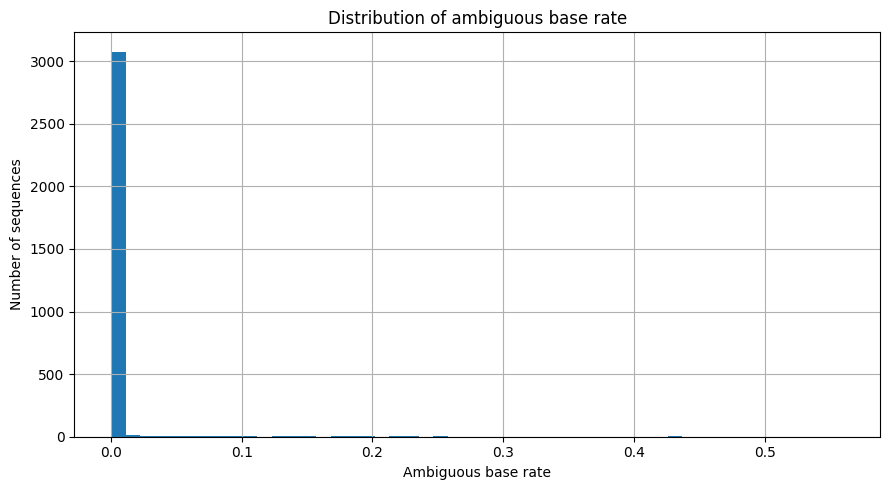

In [40]:
plt.figure(figsize=(9, 5))

plt.hist(strict["ambiguous_rate"].fillna(0), bins=50)

plt.title("Distribution of ambiguous base rate")
plt.xlabel("Ambiguous base rate")
plt.ylabel("Number of sequences")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "10_ambiguous_rate_distribution.png", dpi=300)
plt.show()

### Notes

Cette figure montre la distribution du taux de bases ambiguës dans le dataset strict.

Si la majorité des séquences est concentrée près de 0, cela signifie que la plupart des séquences contiennent peu ou pas de bases incertaines.

Une longue queue vers la droite indiquerait la présence de quelques séquences plus bruitées. Ces séquences ne sont pas forcément inutiles, mais elles sont moins adaptées aux analyses sensibles comme les k-mers ou la phylogénie.

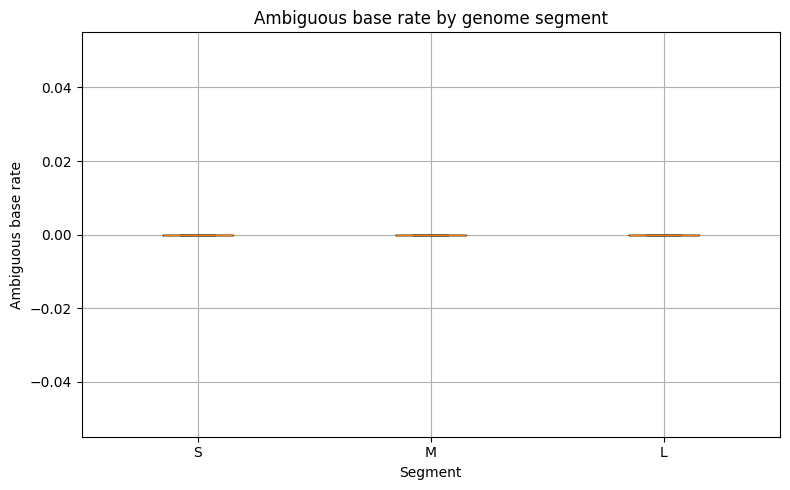

In [41]:
segment_order = [s for s in ["S", "M", "L"] if s in strict["segment"].dropna().unique()]

plt.figure(figsize=(8, 5))

data = [
    strict.loc[strict["segment"] == seg, "ambiguous_rate"].fillna(0)
    for seg in segment_order
]

plt.boxplot(data, labels=segment_order, showfliers=False)

plt.title("Ambiguous base rate by genome segment")
plt.xlabel("Segment")
plt.ylabel("Ambiguous base rate")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "11_ambiguous_rate_by_segment.png", dpi=300)
plt.show()

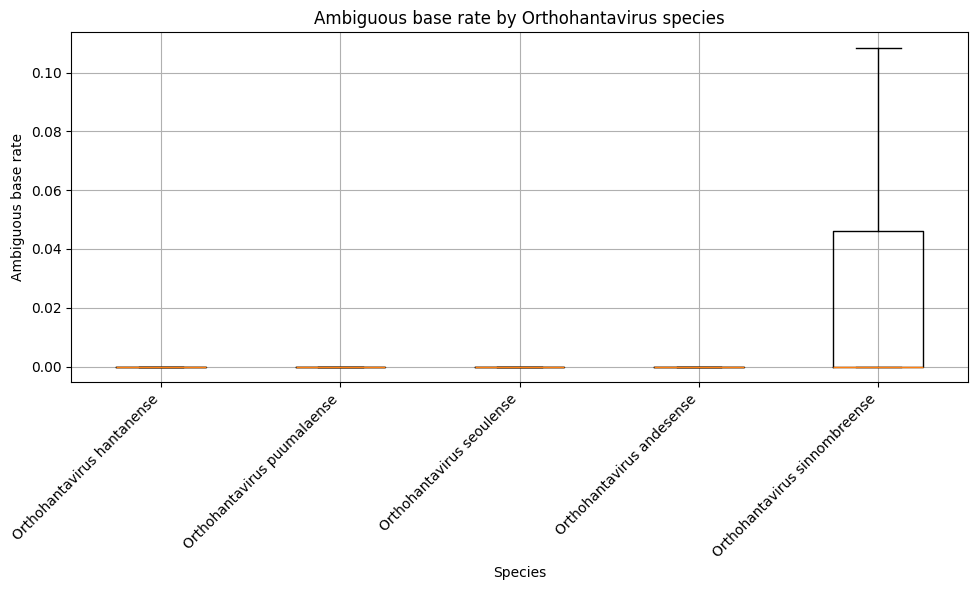

In [42]:
species_order = species_counts["species"].tolist()

plt.figure(figsize=(10, 6))

data = [
    strict.loc[strict[species_col] == species, "ambiguous_rate"].fillna(0)
    for species in species_order
]

plt.boxplot(data, labels=species_order, showfliers=False)

plt.title("Ambiguous base rate by Orthohantavirus species")
plt.xlabel("Species")
plt.ylabel("Ambiguous base rate")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "12_ambiguous_rate_by_species.png", dpi=300)
plt.show()

### Notes

Cette figure compare la qualité des séquences entre espèces virales.

L’objectif est de vérifier si une espèce contient proportionnellement plus de séquences ambiguës que les autres.

Si une espèce présente une distribution plus élevée ou plus dispersée, il faudra être prudent dans les analyses comparatives, car ses signatures moléculaires pourraient être davantage influencées par la qualité des séquences que par de vraies différences biologiques.

In [43]:
ambiguity_summary = (
    strict
    .groupby([species_col, "segment"])["ambiguous_rate"]
    .describe()
    .round(5)
)

ambiguity_summary

count     mean      std  min  25%     50%      75%      max
target_scientific_name        segment                                                             
Orthohantavirus andesense     L         62.0  0.00056  0.00247  0.0  0.0  0.0000  0.00000  0.01731
                              M         75.0  0.00550  0.02497  0.0  0.0  0.0000  0.00000  0.17766
                              S         96.0  0.00006  0.00020  0.0  0.0  0.0000  0.00000  0.00108
Orthohantavirus hantanense    L        272.0  0.00000  0.00001  0.0  0.0  0.0000  0.00000  0.00016
                              M        334.0  0.00001  0.00014  0.0  0.0  0.0000  0.00000  0.00249
                              S        452.0  0.00002  0.00024  0.0  0.0  0.0000  0.00000  0.00388
Orthohantavirus puumalaense   L        125.0  0.00138  0.00714  0.0  0.0  0.0000  0.00015  0.05930
                              M        140.0  0.00104  0.00711  0.0  0.0  0.0000  0.00000  0.07752
                              S        611.0  0.00003  0.00038  0.0  0.0  0.0000  0.00000  0.00710
Orthohantavirus seoulense     L        207.0  0.00209  0.01978  0.0  0.0  0.0000  0.00000  0.25496
                              M        284.0  0.00021  0.00158  0.0  0.0  0.0000  0.00000  0.01983
                              S        324.0  0.00121  0.00842  0.0  0.0  0.0000  0.00000  0.09507
Orthohantavirus sinnombreense L         52.0  0.08589  0.12744  0.0  0.0  0.0194  0.12289  0.56026
                              M         61.0  0.04508  0.09737  0.0  0.0  0.0000  0.02408  0.43019
                              S         70.0  0.03017  0.07425  0.0  0.0  0.0000  0.01124  0.47897

### Notes

Ce tableau résume le taux de bases ambiguës pour chaque combinaison **espèce × segment**.

Il est utile pour repérer précisément les groupes de séquences qui pourraient être plus bruités.

Cette analyse est plus informative qu’une simple moyenne globale, car elle permet d’identifier si le problème vient d’une espèce particulière, d’un segment particulier, ou d’une combinaison des deux.

In [44]:
ambiguity_summary.to_csv(TABLES_DIR / "12_ambiguity_summary_by_species_segment.csv")

print("Ambiguity summary saved.")

Ambiguity summary saved.


## 11. Sequence completeness status

We now inspect whether nucleotide sequences are annotated as complete or partial.

This is important because complete sequences are usually preferable for conservative phylogenetic analyses, while high-quality partial sequences can still be useful for exploratory molecular feature analysis.

In [45]:
completeness_counts = (
    strict["nuc_completeness"]
    .fillna("UNKNOWN")
    .value_counts()
    .rename_axis("nuc_completeness")
    .reset_index(name="n_sequences")
)

completeness_counts

,nuc_completeness,n_sequences
0,PARTIAL,2445
1,COMPLETE,720


### Notes

Ici, on compte combien de séquences sont annotées comme complètes, partielles ou inconnues.

Cette information est importante pour choisir le bon sous-dataset selon l’analyse.

Un dataset contenant beaucoup de séquences partielles peut rester très utile pour l’exploration, mais il faut être plus prudent pour les comparaisons phylogénétiques.

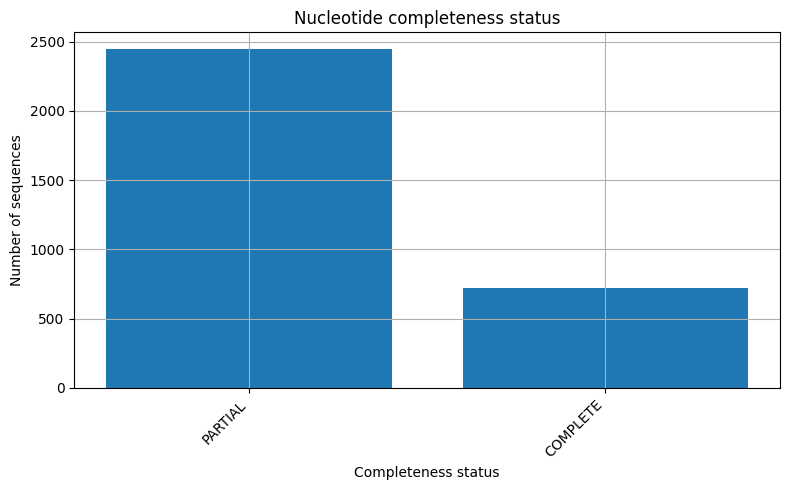

In [46]:
plt.figure(figsize=(8, 5))

plt.bar(completeness_counts["nuc_completeness"], completeness_counts["n_sequences"])

plt.title("Nucleotide completeness status")
plt.xlabel("Completeness status")
plt.ylabel("Number of sequences")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "13_completeness_counts.png", dpi=300)
plt.show()

### Notes

Cette figure montre visuellement la proportion de séquences complètes, partielles ou non renseignées.

Si les séquences complètes représentent une fraction limitée du dataset, cela signifie qu’il faudra distinguer les usages :

- dataset large pour les analyses exploratoires ;
- dataset plus conservateur pour la phylogénie.

Ce n’est pas forcément un problème, mais c’est une limite à documenter clairement.

In [47]:
completeness_by_segment = pd.crosstab(
    strict["segment"].fillna("Unknown"),
    strict["nuc_completeness"].fillna("UNKNOWN")
)

completeness_by_segment

nuc_completeness,COMPLETE,PARTIAL
segment,,
L,232,486
M,222,672
S,266,1287


### Notes

Ce tableau croise le statut de complétude avec le segment viral.

Il permet de voir si certains segments sont plus souvent complets ou partiels.

On peut s’attendre à ce que le segment **L**, plus long, soit plus souvent partiel ou moins représenté en version complète que le segment **S**, qui est plus court.

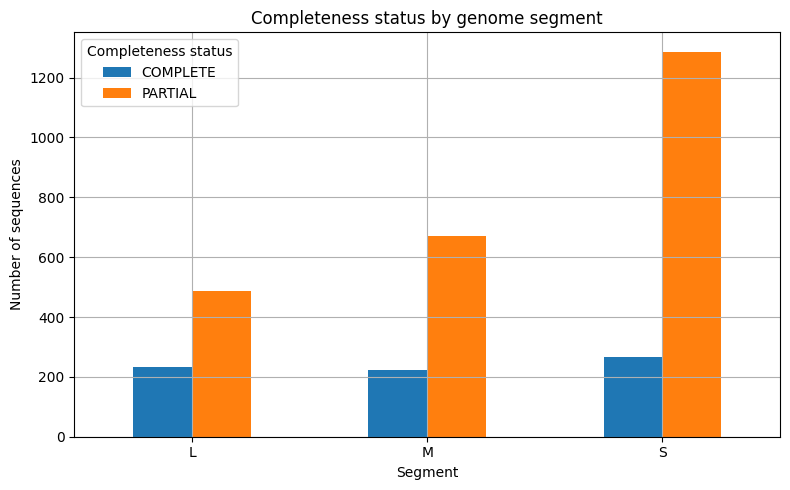

In [48]:
completeness_by_segment.plot(kind="bar", figsize=(8, 5))

plt.title("Completeness status by genome segment")
plt.xlabel("Segment")
plt.ylabel("Number of sequences")
plt.xticks(rotation=0)
plt.legend(title="Completeness status")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "14_completeness_by_segment.png", dpi=300)
plt.show()

### Notes

Cette figure compare le statut de complétude entre les segments **S, M et L**.

Elle permet de voir si la disponibilité des séquences complètes est homogène ou non entre segments.

Si le segment **S** est beaucoup plus représenté en séquences complètes, cela peut s’expliquer par sa taille plus courte et par le fait qu’il est plus souvent ciblé dans les études de séquençage. À l’inverse, le segment **L** peut être plus difficile à obtenir en entier.

In [49]:
completeness_by_species = pd.crosstab(
    strict[species_col].fillna("Unknown"),
    strict["nuc_completeness"].fillna("UNKNOWN")
)

completeness_by_species

nuc_completeness,COMPLETE,PARTIAL
target_scientific_name,,
Orthohantavirus andesense,146,87
Orthohantavirus hantanense,223,835
Orthohantavirus puumalaense,110,766
Orthohantavirus seoulense,231,584
Orthohantavirus sinnombreense,10,173


### Notes

Ce tableau croise le statut de complétude avec l’espèce virale.

Il permet de vérifier si certaines espèces disposent de plus de séquences complètes que d’autres.

C’est important pour la suite : une espèce très bien représentée en séquences complètes pourra être plus facile à intégrer dans une phylogénie fiable, tandis qu’une espèce avec peu de séquences complètes devra être interprétée avec prudence.

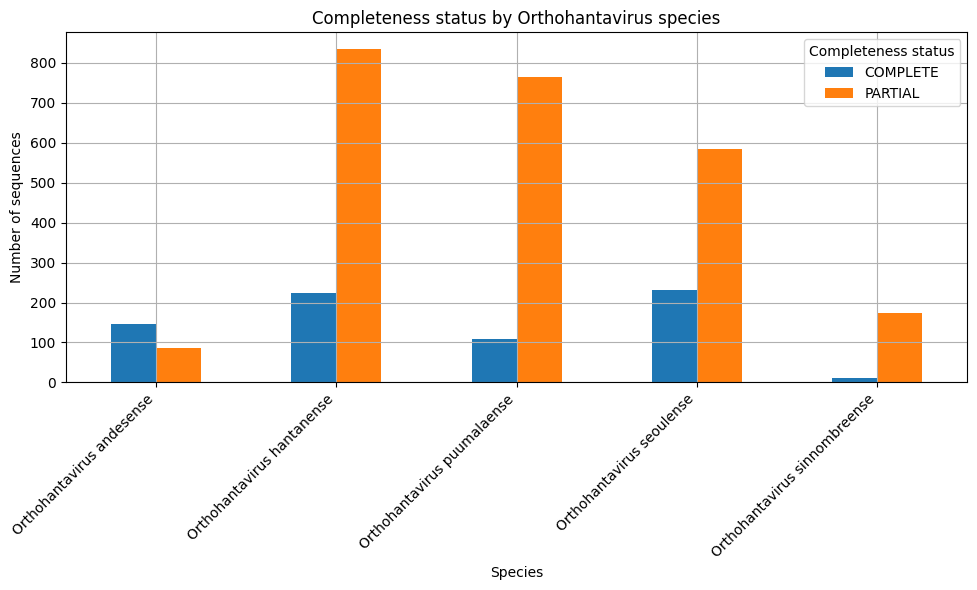

In [50]:
completeness_by_species.plot(kind="bar", figsize=(10, 6))

plt.title("Completeness status by Orthohantavirus species")
plt.xlabel("Species")
plt.ylabel("Number of sequences")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Completeness status")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "15_completeness_by_species.png", dpi=300)
plt.show()

### Notes

Cette figure montre la répartition des séquences complètes et partielles pour chaque espèce.

Elle permet d’évaluer quelles espèces sont les plus adaptées à une analyse phylogénétique stricte.

Si une espèce contient beaucoup de séquences mais peu de séquences complètes, elle reste utile pour l’analyse exploratoire, mais moins idéale pour construire un arbre phylogénétique conservateur.

In [51]:
complete_reference = strict[
    strict["nuc_completeness"].fillna("").str.upper().eq("COMPLETE")
    & (strict["ambiguous_rate"].fillna(0) <= 0.05)
].copy()

print("Strict dataset:", len(strict))
print("Complete reference dataset:", len(complete_reference))

complete_reference_path = DATA_DIR / "orthohantavirus_sequences_complete_reference.csv"
complete_reference.to_csv(complete_reference_path, index=False)

print("Saved:", complete_reference_path)

Strict dataset: 3165
Complete reference dataset: 720
Saved: C:\Users\Utilisateur\Documents\GitHub\Hantavirus-Analysis\data\processed\orthohantavirus_sequences_complete_reference.csv


### Notes

Ici, on crée un dataset plus conservateur appelé `complete_reference`.

Il ne contient que les séquences annotées comme complètes et avec un taux de bases ambiguës inférieur ou égal à 5 %.

Ce dataset sera plus petit que le dataset strict, mais il sera plus adapté pour des analyses phylogénétiques prudentes, où les séquences partielles peuvent introduire des biais.

## Interprétation générale — qualité et complétude des séquences

L’analyse de la qualité montre que la majorité des séquences du dataset strict présente un faible taux de bases ambiguës.

Cela permet de créer un dataset `analysis_ready`, plus propre, qui sera utilisé pour les analyses de signatures moléculaires : fréquences nucléotidiques, k-mers, PCA et clustering.

L’analyse de la complétude montre qu’une partie du dataset contient des séquences partielles. Cela ne rend pas le dataset inutilisable, mais cela impose de distinguer les usages.

Pour les analyses exploratoires, le dataset `analysis_ready` est recommandé.

Pour les analyses phylogénétiques plus conservatrices, le dataset `complete_reference` est préférable, même s’il contient moins de séquences.

## 12. Metadata coverage

We now evaluate the availability of metadata associated with the nucleotide sequences.

Metadata are essential for linking molecular data to epidemiological interpretation. In this project, the most important metadata fields are:

- country of collection;
- collection date;
- host or reservoir;
- isolate or strain information, when available.

In [52]:
metadata_cols = ["country", "collection_date", "host", "isolate", "region"]

metadata_cols = [
    col for col in metadata_cols
    if col in strict.columns
]

metadata_cols

['country', 'collection_date', 'host', 'isolate', 'region']

In [53]:
metadata_coverage = []

for col in metadata_cols:
    non_missing = (
        strict[col].notna()
        & (strict[col].astype(str).str.strip() != "")
    )
    
    metadata_coverage.append({
        "metadata_field": col,
        "n_available": int(non_missing.sum()),
        "pct_available": round(float(non_missing.mean() * 100), 2),
    })

metadata_coverage = (
    pd.DataFrame(metadata_coverage)
    .sort_values("pct_available", ascending=False)
)

metadata_coverage

,metadata_field,n_available,pct_available
3,isolate,3155,99.68
0,country,2997,94.69
1,collection_date,2592,81.90
2,host,0,0.00
4,region,0,0.00


### Notes

Ici, on calcule la proportion de valeurs disponibles pour chaque champ de métadonnées.

Le pourcentage de disponibilité indique à quel point chaque information est exploitable dans le dataset.

Par exemple, si le pays est renseigné pour la majorité des séquences, on pourra faire une analyse géographique descriptive. En revanche, si l’hôte est très peu renseigné, il faudra éviter de tirer des conclusions fortes sur les réservoirs animaux à partir de ce dataset seul.

In [54]:
metadata_coverage.to_csv(TABLES_DIR / "13_metadata_coverage.csv", index=False)

print("Metadata coverage table saved.")

Metadata coverage table saved.


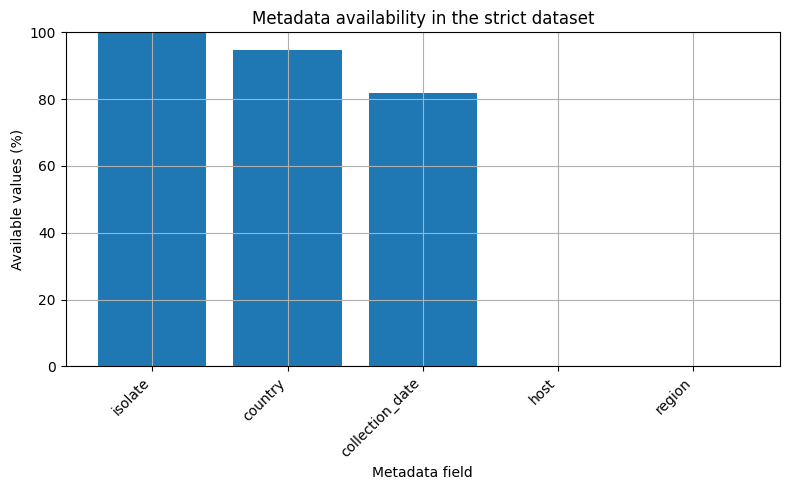

In [55]:
plt.figure(figsize=(8, 5))

plt.bar(
    metadata_coverage["metadata_field"],
    metadata_coverage["pct_available"]
)

plt.title("Metadata availability in the strict dataset")
plt.xlabel("Metadata field")
plt.ylabel("Available values (%)")
plt.ylim(0, 100)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "16_metadata_coverage.png", dpi=300)
plt.show()

In [56]:
top_countries = (
    strict["country"]
    .dropna()
    .astype(str)
    .str.strip()
    .replace("", np.nan)
    .dropna()
    .value_counts()
    .head(20)
    .rename_axis("country")
    .reset_index(name="n_sequences")
)

top_countries

,country,n_sequences
0,China,768
1,South Korea,455
2,Russia,135
3,Argentina,105
4,Belgium,82
5,Russia: the Republic of Tatarstan,73
6,China: Jiangxi,69
7,USA,69
8,France,61
9,Russia: Saratov,56


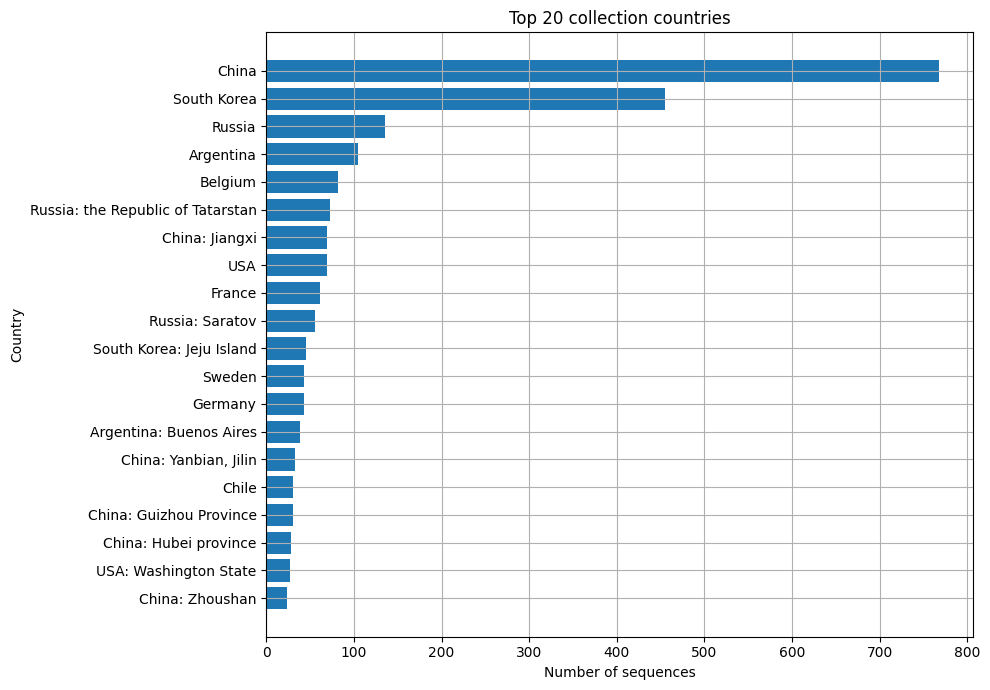

In [57]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_countries["country"][::-1],
    top_countries["n_sequences"][::-1]
)

plt.title("Top 20 collection countries")
plt.xlabel("Number of sequences")
plt.ylabel("Country")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "17_top_20_countries.png", dpi=300)
plt.show()

In [58]:
country_by_species = (
    strict
    .dropna(subset=["country"])
    .groupby([species_col, "country"])
    .size()
    .rename("n_sequences")
    .reset_index()
    .sort_values([species_col, "n_sequences"], ascending=[True, False])
)

country_by_species.head(30)

,target_scientific_name,country,n_sequences
0,Orthohantavirus andesense,Argentina,105
1,Orthohantavirus andesense,Argentina: Buenos Aires,34
7,Orthohantavirus andesense,Chile,31
12,Orthohantavirus andesense,Switzerland,12
2,Orthohantavirus andesense,Argentina: Entre Rios,3
3,Orthohantavirus andesense,Bolivia,3
4,Orthohantavirus andesense,Brazil,3
8,Orthohantavirus andesense,Chile: Region de Los Rios,3
9,Orthohantavirus andesense,Chile: Region de los Rios,3
10,Orthohantavirus andesense,Paraguay,2


### Notes

Ici, on regarde les pays de collecte les plus représentés pour chaque espèce virale.

Cette analyse est plus informative que le simple top pays global, car chaque Orthohantavirus a une distribution géographique spécifique.

Elle permet de vérifier si les données récupérées correspondent globalement aux zones attendues pour certaines espèces, par exemple Andes virus en Amérique du Sud, Sin Nombre en Amérique du Nord, ou Puumala en Europe.

In [59]:
top5_countries_by_species = (
    country_by_species
    .groupby(species_col)
    .head(5)
)

top5_countries_by_species

,target_scientific_name,country,n_sequences
0,Orthohantavirus andesense,Argentina,105
1,Orthohantavirus andesense,Argentina: Buenos Aires,34
7,Orthohantavirus andesense,Chile,31
12,Orthohantavirus andesense,Switzerland,12
2,Orthohantavirus andesense,Argentina: Entre Rios,3
36,Orthohantavirus hantanense,South Korea,400
14,Orthohantavirus hantanense,China,298
23,Orthohantavirus hantanense,China: Jiangxi,62
43,Orthohantavirus hantanense,South Korea: Jeju Island,45
30,Orthohantavirus hantanense,"China: Yanbian, Jilin",33


### Notes

Ce tableau extrait les 5 pays les plus représentés pour chaque espèce.

Il donne une vue plus lisible de la distribution géographique dominante de chaque virus.

Cette information pourra servir plus tard à relier les signatures moléculaires aux zones de circulation principales, tout en gardant en tête que les données GenBank reflètent aussi les efforts de séquençage et de surveillance.

In [60]:
top_countries.to_csv(TABLES_DIR / "14_top_20_countries.csv", index=False)
country_by_species.to_csv(TABLES_DIR / "15_country_by_species.csv", index=False)
top5_countries_by_species.to_csv(TABLES_DIR / "16_top5_countries_by_species.csv", index=False)

print("Country metadata tables saved.")

Country metadata tables saved.


In [61]:
if "host" in strict.columns:
    host_counts = (
        strict["host"]
        .dropna()
        .astype(str)
        .str.strip()
        .replace("", np.nan)
        .dropna()
        .value_counts()
        .head(20)
        .rename_axis("host")
        .reset_index(name="n_sequences")
    )
    
    display(host_counts)
else:
    print("No host column available in strict dataset.")

,host,n_sequences


## Interprétation générale — métadonnées

L’analyse des métadonnées permet de déterminer dans quelle mesure le dataset moléculaire peut être relié à une interprétation épidémiologique.

Les champs comme le pays et la date de collecte sont particulièrement importants pour étudier la distribution géographique et temporelle des séquences.

Si ces champs sont bien renseignés, le dataset pourra être utilisé pour des analyses descriptives par région ou par période.

En revanche, si le champ `host` est incomplet, il faudra éviter de tirer des conclusions fortes sur les réservoirs animaux à partir de ce dataset seul.

Globalement, cette étape montre que les séquences moléculaires peuvent être exploitées pour une première lecture géographique, mais que certaines métadonnées restent limitées et devront être discutées dans les limites du projet.

## 13. Collection year and temporal coverage

We now analyze the temporal coverage of the molecular dataset.

The goal is to extract the collection year from the `collection_date` field and evaluate how sequences are distributed over time.

This is useful because sequence databases may be biased toward specific years, outbreaks, countries or surveillance programs.

In [62]:
def extract_year(value):
    """
    Extract a year from a collection date field.

    The function searches for a 4-digit year starting with 19 or 20.
    It returns NaN if no valid year is found.
    """
    if pd.isna(value):
        return np.nan
    
    text = str(value)
    match = re.search(r"(19|20)\d{2}", text)
    
    if match:
        return int(match.group(0))
    
    return np.nan


strict = strict.copy()
strict["collection_year"] = strict["collection_date"].apply(extract_year)

strict[["collection_date", "collection_year"]].head(20)

,collection_date,collection_year
0,2016,2016.0
1,2022,2022.0
2,NaN,NaN
3,2002,2002.0
4,2002,2002.0
5,2002,2002.0
6,2016,2016.0
7,NaN,NaN
8,NaN,NaN
9,NaN,NaN


In [63]:
year_available = strict["collection_year"].notna().sum()
year_missing = strict["collection_year"].isna().sum()

print("Sequences with collection year:", year_available)
print("Sequences without collection year:", year_missing)
print("Percentage with collection year:", round(year_available / len(strict) * 100, 2), "%")

strict["collection_year"].describe()

Sequences with collection year: 2592
Sequences without collection year: 573
Percentage with collection year: 81.9 %


count    2592.000000
mean     2014.792438
std         7.031668
min      1981.000000
25%      2010.000000
50%      2017.000000
75%      2020.000000
max      2026.000000
Name: collection_year, dtype: float64

### Notes

Ici, on mesure combien de séquences possèdent une année de collecte exploitable.

C’est une étape importante car l’analyse temporelle n’a de sens que si une proportion suffisante des séquences possède une date ou au moins une année.

Le résumé statistique permet aussi d’identifier l’année minimale, l’année maximale et la période globale couverte par le dataset.

In [64]:
year_counts = (
    strict
    .dropna(subset=["collection_year"])
    .assign(collection_year=lambda df: df["collection_year"].astype(int))
    .groupby("collection_year")
    .size()
    .rename("n_sequences")
    .reset_index()
)

year_counts.head(), year_counts.tail()

(   collection_year  n_sequences
 0             1981            3
 1             1982            3
 2             1983            2
 3             1984           10
 4             1986            3,
     collection_year  n_sequences
 36             2022          138
 37             2023          140
 38             2024           48
 39             2025            6
 40             2026            3)

### Notes

Ici, on compte le nombre de séquences disponibles pour chaque année de collecte.

Ce tableau permet de voir si les données sont réparties régulièrement dans le temps ou si certaines années concentrent beaucoup plus de séquences.

Une forte concentration sur quelques années peut refléter des épisodes de surveillance accrue, des publications importantes ou des outbreaks mieux documentés.

In [65]:
year_counts.to_csv(TABLES_DIR / "17_collection_year_counts.csv", index=False)

print("Collection year table saved.")

Collection year table saved.


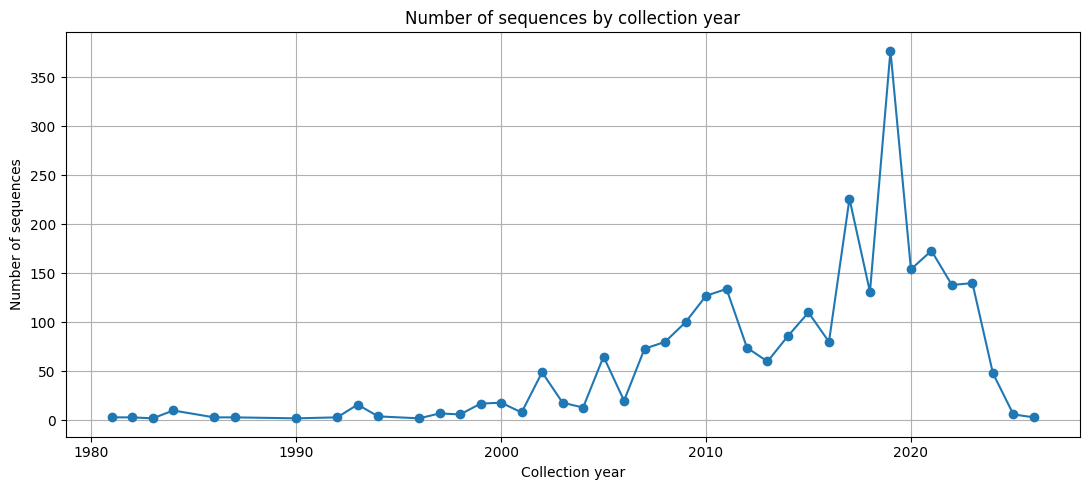

In [66]:
plt.figure(figsize=(11, 5))

plt.plot(
    year_counts["collection_year"],
    year_counts["n_sequences"],
    marker="o"
)

plt.title("Number of sequences by collection year")
plt.xlabel("Collection year")
plt.ylabel("Number of sequences")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "19_collection_year_counts.png", dpi=300)
plt.show()

In [67]:
species_year_counts = (
    strict
    .dropna(subset=["collection_year"])
    .assign(collection_year=lambda df: df["collection_year"].astype(int))
    .groupby([species_col, "collection_year"])
    .size()
    .rename("n_sequences")
    .reset_index()
)

species_year_counts.head(20)

,target_scientific_name,collection_year,n_sequences
0,Orthohantavirus andesense,1990,2
1,Orthohantavirus andesense,1996,1
2,Orthohantavirus andesense,1997,4
3,Orthohantavirus andesense,1998,2
4,Orthohantavirus andesense,1999,6
5,Orthohantavirus andesense,2002,19
6,Orthohantavirus andesense,2006,1
7,Orthohantavirus andesense,2008,2
8,Orthohantavirus andesense,2009,1
9,Orthohantavirus andesense,2010,4


### Notes

Ici, on compte le nombre de séquences par année pour chaque espèce virale.

Cette analyse permet de voir si certaines espèces sont surtout représentées dans certaines périodes.

Par exemple, une espèce peut avoir beaucoup de séquences sur une période courte, tandis qu’une autre peut être représentée plus régulièrement sur plusieurs décennies.

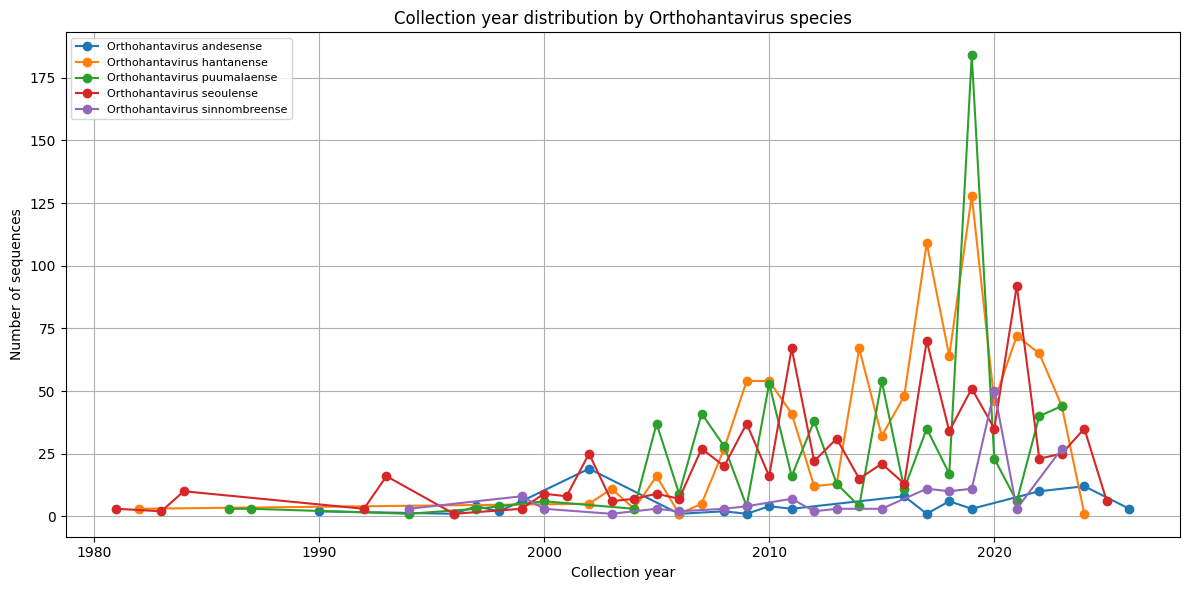

In [68]:
plt.figure(figsize=(12, 6))

for species, subset in species_year_counts.groupby(species_col):
    plt.plot(
        subset["collection_year"],
        subset["n_sequences"],
        marker="o",
        label=species
    )

plt.title("Collection year distribution by Orthohantavirus species")
plt.xlabel("Collection year")
plt.ylabel("Number of sequences")
plt.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "20_collection_year_by_species.png", dpi=300)
plt.show()

In [69]:
segment_year_counts = (
    strict
    .dropna(subset=["collection_year"])
    .assign(collection_year=lambda df: df["collection_year"].astype(int))
    .groupby(["segment", "collection_year"])
    .size()
    .rename("n_sequences")
    .reset_index()
)

segment_year_counts.head(20)

,segment,collection_year,n_sequences
0,L,1981,1
1,L,1982,1
2,L,1983,1
3,L,1984,5
4,L,1986,1
5,L,1987,1
6,L,1990,1
7,L,1992,1
8,L,1993,6
9,L,1994,1


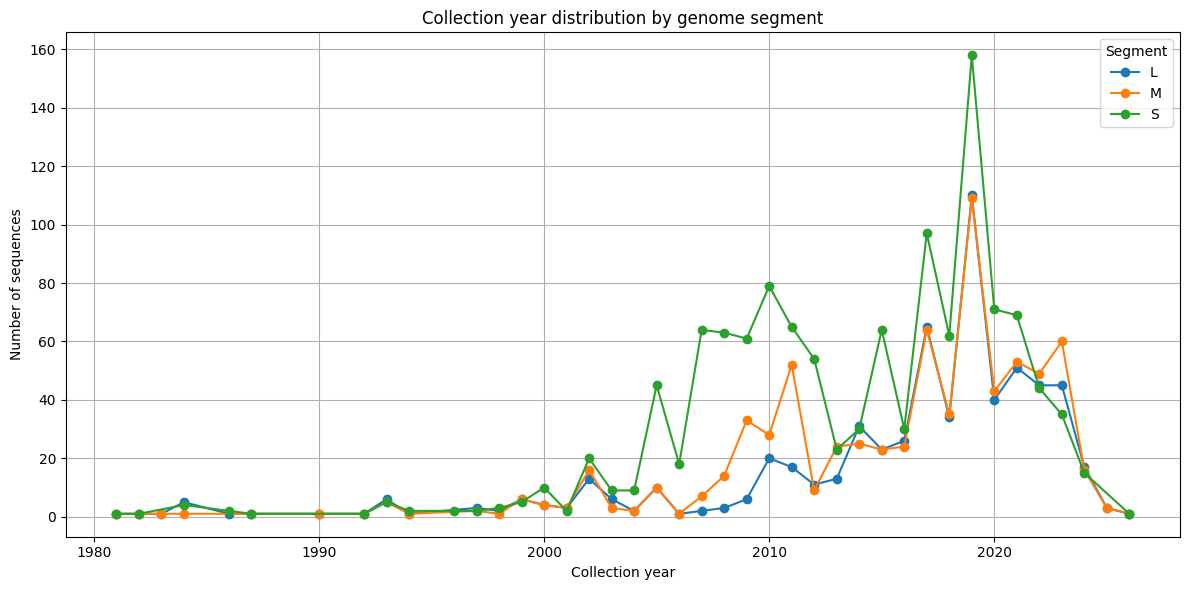

In [70]:
plt.figure(figsize=(12, 6))

for segment, subset in segment_year_counts.groupby("segment"):
    plt.plot(
        subset["collection_year"],
        subset["n_sequences"],
        marker="o",
        label=segment
    )

plt.title("Collection year distribution by genome segment")
plt.xlabel("Collection year")
plt.ylabel("Number of sequences")
plt.legend(title="Segment")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "21_collection_year_by_segment.png", dpi=300)
plt.show()

### Notes

Cette figure compare la représentation temporelle des segments **S, M et L**.

Elle permet de voir si les trois segments sont disponibles de manière homogène dans le temps.

Si le segment **S** est systématiquement plus représenté, cela peut s’expliquer par sa taille plus courte et son utilisation fréquente pour l’identification ou la classification des hantavirus.

Si les segments **M** et **L** sont moins nombreux, il faudra en tenir compte pour les analyses phylogénétiques segment par segment.

In [71]:
temporal_coverage_by_species = (
    strict
    .dropna(subset=["collection_year"])
    .assign(collection_year=lambda df: df["collection_year"].astype(int))
    .groupby(species_col)
    .agg(
        first_year=("collection_year", "min"),
        last_year=("collection_year", "max"),
        n_years_represented=("collection_year", "nunique"),
        n_sequences_with_year=("collection_year", "count")
    )
    .reset_index()
)

temporal_coverage_by_species

,target_scientific_name,first_year,last_year,n_years_represented,n_sequences_with_year
0,Orthohantavirus andesense,1990,2026,18,88
1,Orthohantavirus hantanense,1982,2024,24,921
2,Orthohantavirus puumalaense,1986,2023,26,680
3,Orthohantavirus seoulense,1981,2025,33,749
4,Orthohantavirus sinnombreense,1994,2023,18,154


### Notes

Ce tableau résume la couverture temporelle pour chaque espèce virale.

On obtient pour chaque virus :

- la première année disponible ;
- la dernière année disponible ;
- le nombre d’années représentées ;
- le nombre de séquences avec une année exploitable.

Cette synthèse permet de savoir quelles espèces ont une bonne couverture temporelle et lesquelles sont plus limitées.

In [72]:
species_year_counts.to_csv(TABLES_DIR / "18_collection_year_by_species.csv", index=False)
segment_year_counts.to_csv(TABLES_DIR / "19_collection_year_by_segment.csv", index=False)
temporal_coverage_by_species.to_csv(TABLES_DIR / "20_temporal_coverage_by_species.csv", index=False)

print("Temporal coverage tables saved.")

Temporal coverage tables saved.


## Interprétation générale — couverture temporelle

L’analyse temporelle montre comment les séquences du dataset strict sont réparties selon leur année de collecte.

Cette couverture temporelle est utile pour contextualiser les données moléculaires, mais elle ne doit pas être interprétée directement comme une courbe d’incidence des infections.

Les pics de séquences peuvent refléter des événements de surveillance, des études ciblées, des outbreaks documentés ou des biais de dépôt dans les bases publiques.

L’analyse par espèce et par segment permet également de vérifier si certains virus ou certains segments sont mieux représentés que d’autres au fil du temps.

Pour la suite du projet, cette information sera importante afin d’interpréter prudemment les analyses moléculaires et phylogénétiques.

## 14. Final dataset comparison

We now compare the different dataset versions generated during the quality-control process.

The goal is to decide which dataset should be used for each downstream analysis:

- broad molecular audit;
- k-mer and PCA analysis;
- exploratory classification;
- conservative phylogenetic analysis.

In [73]:
if "analysis_ready" not in globals():
    analysis_ready = strict[strict["ambiguous_rate"].fillna(0) <= 0.05].copy()

if "complete_reference" not in globals():
    complete_reference = strict[
        strict["nuc_completeness"].fillna("").str.upper().eq("COMPLETE")
        & (strict["ambiguous_rate"].fillna(0) <= 0.05)
    ].copy()

print("clean_all:", clean_all.shape)
print("strict:", strict.shape)
print("analysis_ready:", analysis_ready.shape)
print("complete_reference:", complete_reference.shape)

clean_all: (6747, 33)
strict: (3165, 34)
analysis_ready: (3109, 33)
complete_reference: (720, 33)


In [74]:
datasets = {
    "clean_all": clean_all,
    "strict": strict,
    "analysis_ready": analysis_ready,
    "complete_reference": complete_reference,
}

comparison_rows = []

for dataset_name, df in datasets.items():
    row = {
        "dataset": dataset_name,
        "n_sequences": len(df),
        "n_species": df[species_col].nunique() if species_col in df.columns else np.nan,
        "n_segments": df["segment"].nunique() if "segment" in df.columns else np.nan,
        "mean_length": round(df["length"].mean(), 2) if "length" in df.columns else np.nan,
        "median_length": round(df["length"].median(), 2) if "length" in df.columns else np.nan,
        "mean_gc_content": round(df["gc_content"].mean(), 4) if "gc_content" in df.columns else np.nan,
        "median_gc_content": round(df["gc_content"].median(), 4) if "gc_content" in df.columns else np.nan,
        "mean_ambiguous_rate": round(df["ambiguous_rate"].mean(), 5) if "ambiguous_rate" in df.columns else np.nan,
        "pct_with_country": round(
            (
                df["country"].notna()
                & (df["country"].astype(str).str.strip() != "")
            ).mean() * 100,
            2
        ) if "country" in df.columns else np.nan,
        "pct_with_collection_year": round(
            df["collection_year"].notna().mean() * 100,
            2
        ) if "collection_year" in df.columns else np.nan,
    }
    
    comparison_rows.append(row)

dataset_comparison = pd.DataFrame(comparison_rows)

dataset_comparison

,dataset,n_sequences,n_species,n_segments,mean_length,median_length,mean_gc_content,median_gc_content,mean_ambiguous_rate,pct_with_country,pct_with_collection_year
0,clean_all,6747,5,3,1802.09,1008.0,0.4003,0.3996,0.00196,91.54,NaN
1,strict,3165,5,3,3272.32,3366.0,0.4017,0.3994,0.00348,94.69,81.9
2,analysis_ready,3109,5,3,3252.98,3293.0,0.4020,0.3996,0.00038,94.60,NaN
3,complete_reference,720,5,3,3882.27,3651.0,0.3959,0.3958,0.00008,95.83,NaN


### Notes

Ce tableau compare les différentes versions du dataset selon plusieurs critères : nombre de séquences, nombre d’espèces, nombre de segments, longueur moyenne, GC content moyen, taux moyen de bases ambiguës et disponibilité des métadonnées.

L’objectif n’est pas de choisir automatiquement le plus grand dataset, mais de choisir le dataset le plus adapté à chaque type d’analyse.

Un dataset plus grand peut être utile pour l’exploration, mais un dataset plus strict peut être plus fiable pour les analyses sensibles comme la phylogénie.

In [75]:
dataset_comparison.to_csv(TABLES_DIR / "21_dataset_comparison.csv", index=False)

print("Dataset comparison table saved.")

Dataset comparison table saved.


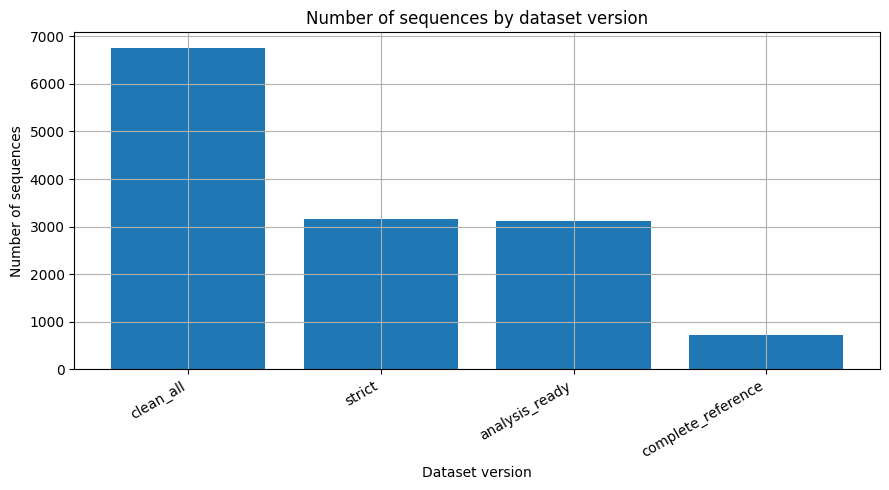

In [76]:
plt.figure(figsize=(9, 5))

plt.bar(
    dataset_comparison["dataset"],
    dataset_comparison["n_sequences"]
)

plt.title("Number of sequences by dataset version")
plt.xlabel("Dataset version")
plt.ylabel("Number of sequences")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "22_dataset_size_comparison.png", dpi=300)
plt.show()

### Notes

Cette figure montre la réduction progressive du nombre de séquences entre les différentes versions du dataset.

On observe normalement une diminution logique :

- `clean_all` contient le plus grand nombre de séquences ;
- `strict` est plus petit, car il conserve seulement les séquences avec des longueurs biologiquement plausibles ;
- `analysis_ready` est très proche du dataset strict, car peu de séquences sont retirées à cause des bases ambiguës ;
- `complete_reference` est beaucoup plus petit, car il ne garde que les séquences complètes et peu ambiguës.

Cette figure montre bien le compromis entre quantité de données et niveau de confiance.

In [77]:
recommended_usage = pd.DataFrame([
    {
        "dataset": "clean_all",
        "recommended_use": "Broad inspection and traceability",
        "reason": "Largest cleaned dataset, but may include more partial or less suitable sequences."
    },
    {
        "dataset": "strict",
        "recommended_use": "Main molecular audit",
        "reason": "Biologically plausible segment lengths; useful for descriptive analysis."
    },
    {
        "dataset": "analysis_ready",
        "recommended_use": "K-mers, PCA, clustering and exploratory classification",
        "reason": "Strict sequences with low ambiguity rate; good balance between size and quality."
    },
    {
        "dataset": "complete_reference",
        "recommended_use": "Conservative phylogenetic analysis",
        "reason": "Complete and low-ambiguity sequences; smaller but more interpretable for phylogeny."
    },
])

recommended_usage

,dataset,recommended_use,reason
0,clean_all,Broad inspection and traceability,"Largest cleaned dataset, but may include more ..."
1,strict,Main molecular audit,Biologically plausible segment lengths; useful...
2,analysis_ready,"K-mers, PCA, clustering and exploratory classi...",Strict sequences with low ambiguity rate; good...
3,complete_reference,Conservative phylogenetic analysis,Complete and low-ambiguity sequences; smaller ...


In [78]:
recommended_usage.to_csv(TABLES_DIR / "22_recommended_dataset_usage.csv", index=False)

print("Recommended usage table saved.")

Recommended usage table saved.


In [79]:
final_expected_files = [
    DATA_DIR / "orthohantavirus_sequences_analysis_ready.csv",
    DATA_DIR / "orthohantavirus_sequences_complete_reference.csv",
    TABLES_DIR / "21_dataset_comparison.csv",
    TABLES_DIR / "22_recommended_dataset_usage.csv",
    FIGURES_DIR / "22_dataset_size_comparison.png",
]

for file in final_expected_files:
    print(file.name, "->", "OK" if file.exists() else "MISSING")

orthohantavirus_sequences_analysis_ready.csv -> OK
orthohantavirus_sequences_complete_reference.csv -> OK
21_dataset_comparison.csv -> OK
22_recommended_dataset_usage.csv -> OK
22_dataset_size_comparison.png -> OK


In [80]:
summary_text = f"""
# Notebook 01 — Molecular Dataset Audit Summary

## Project question

How do S, M and L segment sequences differ across major Orthohantavirus species, and can sequence-level features support molecular classification and epidemiological interpretation?

## Dataset versions

- clean_all: {len(clean_all):,} sequences
- strict: {len(strict):,} sequences
- analysis_ready: {len(analysis_ready):,} sequences
- complete_reference: {len(complete_reference):,} sequences

## Main conclusions

The strict dataset is biologically plausible for first-pass molecular analysis.

The three expected Orthohantavirus genome segments, S, M and L, are represented in the dataset.

Sequence length distributions are coherent with the expected organization of a segmented hantavirus genome: S is the shortest segment, M is intermediate, and L is the longest.

GC content differs between segments, suggesting that nucleotide composition may provide useful molecular information.

Most sequences have a low ambiguous base rate, allowing the creation of an analysis-ready dataset for k-mer, PCA and clustering analyses.

A smaller complete-reference dataset was also created for more conservative phylogenetic analyses.

## Main limitations

The dataset is not perfectly balanced between species and segments.

Some sequences are partial.

Host metadata are limited or incomplete.

Country and collection date metadata are useful for descriptive interpretation, but they should not be treated as direct epidemiological incidence data.

## Recommended next step

Use `data/processed/orthohantavirus_sequences_analysis_ready.csv` for Notebook 02 on nucleotide composition, k-mers, PCA and molecular clustering.

Use `data/processed/orthohantavirus_sequences_complete_reference.csv` later for conservative phylogenetic analyses.
"""

summary_path = REPORTS_DIR / "notebook_01_molecular_dataset_audit_summary.md"
summary_path.write_text(summary_text, encoding="utf-8")

print(summary_text)
print("Summary saved to:", summary_path)


# Notebook 01 — Molecular Dataset Audit Summary

## Project question

How do S, M and L segment sequences differ across major Orthohantavirus species, and can sequence-level features support molecular classification and epidemiological interpretation?

## Dataset versions

- clean_all: 6,747 sequences
- strict: 3,165 sequences
- analysis_ready: 3,109 sequences
- complete_reference: 720 sequences

## Main conclusions

The strict dataset is biologically plausible for first-pass molecular analysis.

The three expected Orthohantavirus genome segments, S, M and L, are represented in the dataset.

Sequence length distributions are coherent with the expected organization of a segmented hantavirus genome: S is the shortest segment, M is intermediate, and L is the longest.

GC content differs between segments, suggesting that nucleotide composition may provide useful molecular information.

Most sequences have a low ambiguous base rate, allowing the creation of an analysis-ready dataset for k-

## 15. Final conclusion

This first notebook confirms that the molecular dataset built from NCBI/GenBank is suitable for downstream Orthohantavirus sequence analysis.

The strict dataset contains biologically plausible S, M and L segment sequences across the five selected Orthohantavirus species.

The length distributions are coherent with the expected structure of the segmented hantavirus genome. The GC content analysis also shows structured differences between segments, suggesting that sequence composition features may be informative.

The quality analysis shows that most sequences have a low ambiguous base rate. Based on this, an `analysis_ready` dataset was created and will be used for the next notebook on nucleotide composition, k-mers, PCA and clustering.

A more conservative `complete_reference` dataset was also created for future phylogenetic analyses.

The main limitations are species imbalance, partial sequences and incomplete metadata, especially for host information. These limitations do not prevent molecular analysis, but they must be considered when interpreting the results.

Overall, this notebook validates the dataset as a solid starting point for investigating molecular signatures across Orthohantavirus species and genome segments.

## Notes finales

Ce premier notebook sert à vérifier que le dataset moléculaire est exploitable avant de faire des analyses plus avancées.

Les résultats montrent que le dataset est globalement cohérent biologiquement :

- les segments **S, M et L** sont bien représentés ;
- les longueurs suivent l’ordre attendu : **S < M < L** ;
- le GC content varie selon les segments ;
- la majorité des séquences contient peu de bases ambiguës ;
- les métadonnées pays/date sont partiellement exploitables.

La principale limite est que le dataset n’est pas parfaitement équilibré : certaines espèces et certains segments sont plus représentés que d’autres. De plus, les métadonnées liées à l’hôte sont limitées.

Pour la suite, on utilisera principalement :

- `orthohantavirus_sequences_analysis_ready.csv` pour les k-mers, PCA, clustering et classification exploratoire ;
- `orthohantavirus_sequences_complete_reference.csv` pour la phylogénie prudente.

Le Notebook 1 est donc terminé : il valide le dataset et prépare la suite du projet.